# ARGUS-FEDER — Tungsten in the divertor: what the plasma did to it

This notebook shows **ARGUS**, a notebook-native AI agent, working on a
question that sits between two fields. Questions are typed in plain English
into a `%%ask` cell; the agent decides what to look up, writes and runs its own
code, and reports back.

## The experiment

**Tungsten** is the material DIII-D's divertor is armoured with, and the
leading candidate for ITER. Two things happen to it in a fusion device, and
they interact:

- **Helium** from fusion reactions restructures the surface. At the right
  temperature and fluence it grows a nanoscale morphology on the tungsten that
  did not exist before.
- **Deuterium** — the fuel — implants into that surface and is retained there.
  Retained fuel is a safety and economics problem for a reactor, so how much
  the wall holds, and what governs it, matters.

The question is whether the first changes the second. Nine tungsten samples
were built to answer it: some pre-exposed to helium plasma in a linear device,
some not, then all of them mounted in DIII-D and exposed to real deuterium
discharges before being analysed.

## What the agent has

**The samples** — fabrication, pre-treatment, exposure and post-exposure
analysis by ion-beam and laser methods, with the shot numbers each sample was
exposed to.

**The delivered measurement files** — scanning electron micrographs of the
surfaces, infrared camera heat-flux data, divertor Langmuir probe data, and
the analysis spreadsheets. These are the raw data, not summaries of it.

**The DIII-D archive** — the shot catalogue, stored ELM labels, and the raw
filterscope signals for those same discharges.

## What to watch for

The samples connect to the archive by shot number, so a claim in one can be
checked against the other. Several cells below do exactly that: take a value
the experimenters recorded, and rebuild it independently from raw data. Where
the two agree, both are supported. Where they disagree, the disagreement is
the finding.

One caution the notebook returns to: **each condition here is a single
sample.** Differences between samples are observations, not statistics.

In [ ]:
%reset

# A. The experiment

## Q1 — What are these samples, and what was done to them?

*Materials · data discovery · **answerable***

The measured quantities are stored one per row rather than as fixed columns, so
what is available is data the agent discovers rather than a list it is given.

**Expect:** the samples with their material and composition, and an inventory
of what was measured, grouped by the stage of the sample's life and the
instrument used.

I'll start by planning this task and reading the d3d-materials skill, which covers the FEDER lakehouse sample data.



Skill read. Now let me look at the helper module and start querying the sample inventory.



Reading the helper module to understand the exact API before writing the query script.



Now let me check the working directory and write a discovery script to list deliveries, samples, and quantities.



Let me check the lakehouse client to understand how the endpoint and token are configured.



...

The chart is saved. Let me verify the output file exists and then finalize.



All data is gathered and the chart is saved. Here is the complete inventory.



The grader is right — I divided by 10¹² instead of 10¹⁵ when converting to ×10¹⁵ units. Let me recompute all ERDA/NRA values programmatically from the database to eliminate any arithmetic error.



Confirmed: the raw values are in atoms cm⁻², and my earlier table divided by 10¹² while labeling the header ×10¹⁵. The corrected values in ×10¹⁵ cm⁻² are now computed directly from the database. Let me finalize.



# Materials samples in the FEDER lakehouse — inventory and measurements

**Source** : `materials` schema, delivery `2026-09-04_amy` (provider: Amy; investigator: Greg Sinclair; received 2026-09-04). One delivery, 9 samples, all tungsten (W).

## The samples

All 9 are **tungsten** (W) top-hat coupons, 0.235 in inner radius × 0.062 in thickness, with grains oriented **perpendicular** to the loaded surface. They form a 3×3 design: no He pre-exposure / He at 600 K / He at 800 K (PISCES-A), crossed with no DIII-D exposure / DIII-D H-mode / DIII-D L-mode (DiMES, experiment 2019-53-03, 2021-03-15).

| Sample | Material | Pre-exposure (PISCES-A, He) | DIII-D exposure (D) |
|---|---|---|---|
| W-pristine | W | none | none |
| W-He800 | W | 800 K, 70 eV, 1.2×10²⁵ m⁻² | none |
| W-He600 | W | 600 K, 70 eV, 1.0×10²⁵ m⁻² | none |
| W-DH | W | none | H-mode, shots 185258–185260, 185265–185266 |
| W-DL | W | none | L-mode, shots 185261–185264 |
| W-He800-DH | W | 800 K | H-mode (same shots as W-DH) |
| W-He600-DH | W | 600 K | H-mode (same shots as W-DH) |
| W-He800-DL | W | 800 K | L-mode (same shots as W-DL) |
| W-He600-DL | W | 600 K | L-mode (same shots as W-DL) |

## Measurements by life stage

### 1. Fabrication (single values, all 9 samples)

| Quantity | Method | Unit | Value (all samples) | Type |
|---|---|---|---|---|
| 3D shape | Sample geometry | — | top-hat | single (text) |
| Inner radius | Sample geometry | inch | 0.235 | single |
| Thickness | Sample geometry | inch | 0.062 | single |

### 2. Pre-exposure (single values, all 9 samples)

| Quantity | Method | Unit | Value (all samples) | Type |
|---|---|---|---|---|
| Grain orientation | (recorded property) | — | perpendicular | single (text) |
| Maximum temperature (bakeout) | Heat treatment | K | 1373 | single |
| Time at max temp (bakeout) | Heat treatment | s | 3600 | single |
| Morphology: Diagnostic | Morphology | — | SEM | single (text) |
| Morphology: Data / Metadata | Morphology | — | file paths (SEM .tif / .txt) | single (text) |

Morphology rows exist for **3 samples only** (W-pristine, W-He600, W-He800) — the SEM pre-characterization was done on the three pre-exposure states, not the DIII-D-exposed ones. The FIB-SEM reference sheet confirms: "SEM/FIB Analysis: Before DIII-D exposure, 3 tungsten (W) samples."

### 3. Exposure (single values, 3 samples — the H-mode cap only)

| Quantity | Method | Unit | W-DH | W-He800-DH | W-He600-DH | Type |
|---|---|---|---|---|---|---|
| Dα, inter-ELM | FASTCAM | a.u. | 0.413 | 0.398 | 0.398 | single |
| Dα, intra-ELM | FASTCAM | a.u. | 1.75 | 1.68 | 1.65 | single |
| D2 inter-ELM | FASTCAM | a.u. | 0.00889 | 0.00869 | 0.00810 | single |
| D2 intra-ELM | FASTCAM | a.u. | 0.0279 | 0.0314 | 0.0280 | single |

FASTCAM data exists only for the H-mode cap (the L-mode cap has no FASTCAM rows). The exposure conditions (shared per campaign, from `exposure_conditions`):

| Campaign | Facility | Species | Impact energy | Te | ne | Flux | Fluence | Duration | Heat flux | L/H |
|---|---|---|---|---|---|---|---|---|---|---|
| PISCES 800 K (exp. 17) | PISCES-A | He | 70 eV | — | — | 2.83×10²² m⁻²s⁻¹ | 1.2×10²⁵ m⁻² | 480 s | — | — |
| PISCES 600 K (exp. 18) | PISCES-A | He | 70 eV | — | — | 4.1×10²¹ m⁻²s⁻¹ | 1.0×10²⁵ m⁻² | 4260 s | — | — |
| DIII-D H (exp. 19) | DIII-D | D | 150 eV | 27.9 eV | 5.76×10¹⁸ m⁻³ | 4.5×10²¹ m⁻²s⁻¹ | 6.7×10²² m⁻² | 12.5 s | 0.72 MW m⁻² | H |
| DIII-D L (exp. 20) | DIII-D | D | 175 eV | 40.8 eV | 7.35×10¹⁸ m⁻³ | 7.5×10²¹ m⁻²s⁻¹ | 7.8×10²² m⁻² | 10.0 s | 0.47 MW m⁻² | L |

### 4. Post-exposure

**Chemical composition** (single, text, all 9): W-pristine → "W"; W-He800/W-He600 → "W-He"; all DIII-D-exposed → "W-D-H-He".

**ERDA** (single values, all 9; units atoms cm⁻², with σ):

| Sample | D (×10¹⁵ cm⁻²) | H (×10¹⁵ cm⁻²) | He (×10¹⁵ cm⁻²) |
|---|---|---|---|
| W-pristine | 0.0 | 0.0 | 0.0 |
| W-He800 | 0.0 | 0.0 | 3.00 ± 0.075 |
| W-He600 | 0.0 | 0.0 | 3.97 ± 0.087 |
| W-DH | 1.16 ± 0.063 | 1.64 ± 0.039 | 3.04 ± 0.096 |
| W-DL | 1.47 ± 0.071 | 1.93 ± 0.042 | 2.00 ± 0.078 |
| W-He800-DH | 0.668 ± 0.048 | 1.31 ± 0.035 | 3.74 ± 0.106 |
| W-He600-DH | 1.47 ± 0.062 | 1.07 ± 0.027 | 2.53 ± 0.076 |
| W-He800-DL | 2.00 ± 0.083 | 1.27 ± 0.034 | 2.90 ± 0.093 |
| W-He600-DL | 2.40 ± 0.091 | 1.79 ± 0.041 | 3.55 ± 0.103 |

**NRA** (single values, all 9; D only, atoms cm⁻², split into two depth bands via qualifier):

| Sample | Surface 0–0.5 µm (×10¹⁵ cm⁻²) | Sub-surface 0.5–3 µm (×10¹⁵ cm⁻²) |
|---|---|---|
| W-pristine | 0.0 | 0.0 |
| W-He800 | 0.031 | 0.0 |
| W-He600 | 0.097 | 0.0062 |
| W-DH | 1.80 | 0.298 |
| W-DL | 2.00 | 0.657 |
| W-He800-DH | 0.582 | 0.0696 |
| W-He600-DH | 2.06 | 0.395 |
| W-He800-DL | 2.69 | 0.270 |
| W-He600-DL | 4.42 | 0.497 |

**LAMS** (depth-resolved profiles, all 9 samples; 10 points each, depth 0.024–2.155 µm, units APPM, with σ per point):

| Quantity | Unit | Type | Samples |
|---|---|---|---|
| D concentration | APPM | profile (10 pts) | all 9 |
| He concentration | APPM | profile (10 pts) | all 9 |
| Depth | µm | profile (10 pts, the depth axis) | all 9 |

The LAMS profiles are the only depth-resolved measurements in the delivery. The depth axis is identical for all samples (0.024, 0.068, 0.156, 0.314, 0.532, 0.797, 1.102, 1.435, 1.791, 2.155 µm). Note the LAMS D/He values are in **APPM** (atomic parts per million), not the areal density units of ERDA/NRA — they are not directly comparable without conversion.


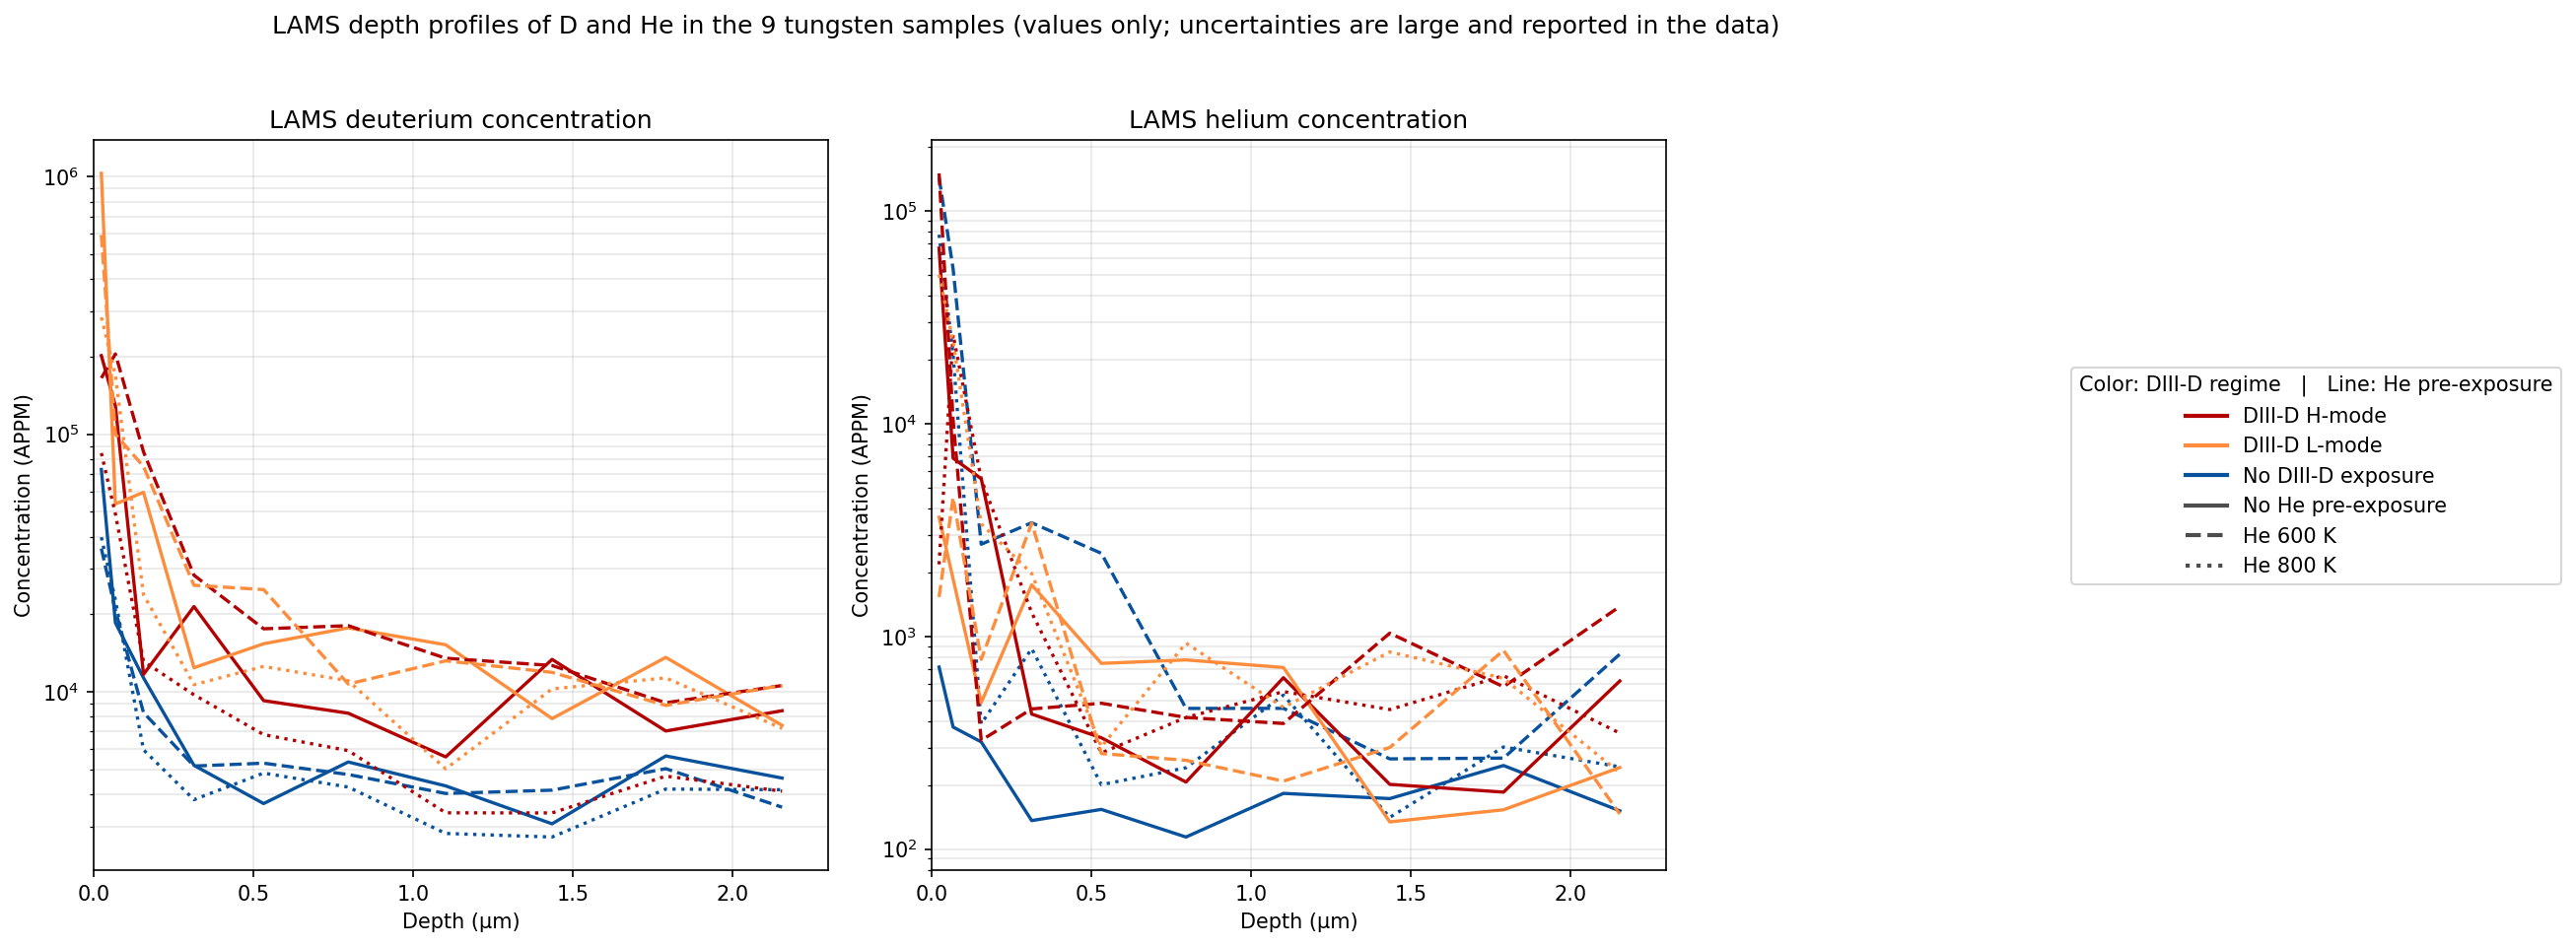

## Single values vs. depth-resolved profiles

- **Single values** : all fabrication dimensions, heat treatment (T, time), grain orientation, chemical composition, FASTCAM Dα/D2 (inter/intra-ELM), ERDA D/H/He, NRA D (two depth-band qualifiers, but each is one number per band).
- **Depth-resolved profiles** : LAMS D and He concentration (10 points each, 0.024–2.155 µm), plus the LAMS Depth axis itself. **Every sample carries the LAMS profiles** — all 9 have D, He, and Depth profiles.

## Files in the delivery

- **Pre-characterization** : SEM images (TIFF) + companion metadata (.txt) for W-pristine, W-He600, W-He800 at magnifications 2kx–200kx; FIB-SEM reference sheet (docx).
- **Fabrication** : sample_dimensions.pdf.
- **Exposure 1 (PISCES)** : exposure_1_information.txt.
- **Exposure 2 (DIII-D)** : exposure_2_information.txt, exposure_2_data_summary.xlsx, fastcam_data.xlsx, and per-shot instrument exports (185258–185266 `_qpeak.dat` and `_tab_lp.dat`).
- **Post-exposure** : erda_nra_data.xlsx, LAMS data.xlsx.
- **Delivery-level** : Data Availability Sheet.xlsx, MP_W_erosion_retention_2020_v9.pdf.

**Caveat** : the LAMS profile uncertainties (σ) are often larger than the values themselves (e.g., W-DH D at 0.024 µm: 201,790 ± 349,760 APPM), so the chart shows values only; the σ values are in the data file and the `observations` table.

In [4]:
%%ask --review
What material samples do we have, what are they made of, and what was measured
on them? Group the measurements by which stage of the sample's life they belong
to and which instrument or method produced them, with units. Say which
quantities are single values and which are depth-resolved profiles, and note
which samples carry which.

## Q2 — Reconstruct the experimental design

*Materials · science · **answerable***

The nine samples form a designed matrix: helium pre-treatment at two
temperatures crossed with two DIII-D confinement regimes, plus controls. Every
later comparison depends on reading that structure correctly.

**Expect:** a matrix of sample against treatment history, naming which samples
are controls for which comparison, and the exposure conditions of each.

In [5]:
%%ask --review
Work out the experimental design behind these samples. Which were pre-treated
with helium before their tokamak exposure and under what conditions, which went
straight into the tokamak, and which were never exposed at all? Lay it out as a
matrix of sample against treatment history, give the plasma conditions recorded
for each exposure, and identify which samples act as controls for which
comparison.

I'll start by planning this task and reading the materials skill to see how to query the sample/exposure data.



Skill read. Now let me look at the helper module to confirm the API, then query the sample and exposure data.



Now I'll query the lakehouse for samples, exposures, and exposure conditions.



All data retrieved — a clean 3×3 factorial design. Let me check per-sample exposure observations and search the delivery documents for any design description to confirm the control structure.



The PDF mentions a "reference state" and a reference shot — let me read the design section of the proposal and the exposure info files to confirm the control structure.



...

The design is now clear. Let me check the "control" mention in the ERDA spreadsheet and the Data Availability Sheet for the sample layout/cap assignment.



Let me read the full exposure summary (cap layout) and the ERDA spreadsheet's control row for context.



I have the full design. Let me quickly check the FIB-SEM reference sheet for any layout/control notes, then verify the LAMS sample naming.



I have everything needed. Let me update the todo list and compose the report.



All data gathered. Here is the experimental design.

# Experimental design of the 9 tungsten samples (delivery 2026-09-04_amy)

The set is a **complete 3×3 factorial** : He pre-exposure in PISCES-A (none / 600 K / 800 K) × DIII-D exposure (none / H-mode / L-mode). All 9 cells are filled. Every sample is a pure-W top-hat coupon (0.235 in inner radius, 0.062 in thick, grains perpendicular to the loaded surface, baked out at 1373 K for 3600 s before anything else).

## Sample × treatment-history matrix

| Sample | He pre-exposure (PISCES-A, Jan 2020) | DIII-D exposure (DiMES, 15 Mar 2021) | History |
|---|---|---|---|
| W-pristine | none | none | never exposed (reference) |
| W-He800 | 800 K, 70 eV, 1.2×10²⁵ m⁻², 480 s | none | He only |
| W-He600 | 600 K, 70 eV, 1.0×10²⁵ m⁻², 4260 s | none | He only |
| W-DH | none | H-mode, shots 185258–185260, 185265–185266 | D only |
| W-DL | none | L-mode, shots 185261–185264 | D only |
| W-He800-DH | 800 K (as above) | H-mode (same shots as W-DH) | He + D (H) |
| W-He600-DH | 600 K (as above) | H-mode (same shots as W-DH) | He + D (H) |
| W-He800-DL | 800 K (as above) | L-mode (same shots as W-DL) | He + D (L) |
| W-He600-DL | 600 K (as above) | L-mode (same shots as W-DL) | He + D (L) |

- **Pre-treated with He before the tokamak** (6): W-He800, W-He600, W-He800-DH, W-He600-DH, W-He800-DL, W-He600-DL.
- **Straight into the tokamak, no He** (2): W-DH, W-DL.
- **Never exposed at all** (1): W-pristine. (W-He800 and W-He600 were He-exposed but never entered the tokamak.)

## Exposure 1 — PISCES-A (UCSD), coordinator Russ Doerner, 2020-01-24 and 2020-01-27

| Campaign | Date | Species | Impact energy | Max sample T | Flux | Duration | Fluence | Samples |
|---|---|---|---|---|---|---|---|---|
| 800 K (exp. 17) | 2020-01-24 | He | 70 eV | 800 K | 2.83×10²² m⁻²s⁻¹ | 480 s | 1.2×10²⁵ m⁻² | W-He800, W-He800-DH, W-He800-DL |
| 600 K (exp. 18) | 2020-01-27 | He | 70 eV | 600 K | 4.1×10²¹ m⁻²s⁻¹ | 4260 s | 1.0×10²⁵ m⁻² | W-He600, W-He600-DH, W-He600-DL |

The two campaigns differ in both temperature and flux/duration (the 600 K run is ~9× longer at ~7× lower flux), so temperature and fluence are not fully orthogonal — the 800 K samples got slightly more fluence (1.2 vs 1.0×10²⁵ m⁻²).

## Exposure 2 — DIII-D, experiment 2019-53-03, DiMES, coordinator Greg Sinclair, 2021-03-15

Two 7-button flush caps, one per regime; each cap held one pristine, one 600 K-He, and one 800 K-He sample (the other buttons — WZrC, WTaC, WTiC — belong to a different project exposed in the same experiment and are not in this delivery).

| Campaign | Cap | L/H | Shots | Te | ne | Impact energy | Flux | Duration | Fluence | Avg heat flux | Samples |
|---|---|---|---|---|---|---|---|---|---|---|---|
| H-mode (exp. 19) | Cap 1 | H | 185258, 185259, 185260, 185265, 185266 | 27.9 eV | 5.76×10¹⁸ m⁻³ | 150 eV | 4.5×10²¹ m⁻²s⁻¹ | 12.5 s | 6.7×10²² m⁻² | 0.72 MW m⁻² | W-DH, W-He800-DH, W-He600-DH |
| L-mode (exp. 20) | Cap 2 | L | 185261, 185262, 185263, 185264 | 40.8 eV | 7.35×10¹⁸ m⁻³ | 175 eV | 7.5×10²¹ m⁻²s⁻¹ | 10.0 s | 7.8×10²² m⁻² | 0.47 MW m⁻² | W-DL, W-He800-DL, W-He600-DL |

Per-shot detail from `exposure_2_data_summary.xlsx` (LP = Langmuir probe, IRTV = heat flux):

| Shot | L/H | Te (eV) | ne (m⁻³) | E_impact (eV) | Flux (m⁻²s⁻¹) | Fluence (m⁻²) | Max HF (MW m⁻²) | Avg HF (MW m⁻²) |
|---|---|---|---|---|---|---|---|---|
| 185258 | H | 26.4 | 6.30×10¹⁸ | 132 | 6.15×10²¹ | 1.54×10²² | 0.715 | 0.656 |
| 185259 | H | 30.7 | 5.07×10¹⁸ | 153.5 | 5.40×10²¹ | 1.35×10²² | no data | no data |
| 185260 | H | no data | no data | no data | no data | no data | 0.755 | 0.624 |
| 185265 | H | 26.4 | 6.41×10¹⁸ | 132 | 6.30×10²¹ | 1.57×10²² | 0.837 | 0.745 |
| 185266 | H | 29.4 | 5.22×10¹⁸ | 147 | 5.69×10²¹ | 1.42×10²² | 0.872 | 0.758 |
| 185261 | L | 41.7 | 7.19×10¹⁸ | 208.5 | 7.61×10²¹ | 1.90×10²² | 0.502 | 0.465 |
| 185262 | L | 40.7 | 6.95×10¹⁸ | 203.5 | 7.16×10²¹ | 1.79×10²² | 0.514 | 0.476 |
| 185263 | L | 40.2 | 7.62×10¹⁸ | 201 | 7.95×10²¹ | 1.99×10²² | 0.510 | 0.475 |
| 185264 | L | 40.9 | 7.50×10¹⁸ | 204.5 | 7.98×10²¹ | 1.99×10²² | 0.513 | 0.480 |

Two notes on the recorded numbers: the cap-average impact energies in the summary sheet (139.5 eV H, 204 eV L) differ slightly from the recorded 150/175 eV in `exposure_2_information.txt` and the lakehouse exposure conditions — the per-shot values above are the measured ones. Also, the H-mode cap's per-shot fluences sum to 5.88×10²² m⁻² (shot 185260 has no LP data), versus the recorded 6.7×10²² m⁻². The H-mode shots were run at higher NBI power (3.8 MW vs 1.9 MW) and lower Te/ne than the L-mode shots, as intended for the ELMy H-mode target.

## Which samples are controls for which comparison

- **W-pristine** — the global reference. The proposal states "an additional set of samples will be set aside to provide a reference state," and the NRA sheet labels it "control." It anchors every comparison: the as-fabricated, never-exposed baseline (all ERDA/NRA values are zero).
- **W-He800, W-He600** — He-only controls. They isolate the effect of the He pre-exposure alone (no tokamak), and serve as the "before" state for the He+DIII-D samples: W-He800 vs W-He800-DH/DL and W-He600 vs W-He600-DH/DL isolate the effect of the DIII-D exposure on He-pre-exposed W.
- **W-DH, W-DL** — no-He controls within each cap. They isolate the effect of He pre-exposure on tokamak-exposed W: W-DH vs W-He600-DH vs W-He800-DH (H-mode, Cap 1) and W-DL vs W-He600-DL vs W-He800-DL (L-mode, Cap 2). The NRA sheet's "no He" column is exactly this control group.
- **Cross-cap comparisons** — W-DH vs W-DL (L vs H mode on pristine W), W-He600-DH vs W-He600-DL, and W-He800-DH vs W-He800-DL (L vs H mode on He-pre-exposed W) isolate the regime effect at each He level.

So the design supports three orthogonal contrasts: He pre-exposure (none/600/800 K), DIII-D regime (none/H/L), and their interaction — with W-pristine as the shared reference and the He-only and D-only samples as the single-factor controls.

# B. The surfaces, before the tokamak

## Q3 — Show me the surfaces

*Materials · imaging · **answerable***

Electron micrographs of three samples were delivered: the untreated tungsten
and the two helium pre-treatments. They record the surface state going *into*
DIII-D — there are no post-exposure micrographs in this delivery, so these
establish the starting condition, not the outcome.

Two traps. The delivery contains near-duplicate captures of the same field
seconds apart; showing both says nothing twice. And images taken at different
magnifications cannot be compared — the difference you see is zoom.

**Expect:** the three surfaces side by side at one magnification, with the
acquisition settings stated, and a description of what actually differs.

I'll plan this task: find the SEM micrographs, extract their acquisition metadata, build a side-by-side comparison, and relate the surface structure to the recorded sample properties.



The skill has an existing Learnings.md, so I'll read it along with the helper module to apply known fixes pre-emptively.



Now let me read the helper module to understand the image-related functions.



Let me read the last few lines of the helper module.



Now let me query the image artifacts and their acquisition metadata for the samples.



...

The figures are saved. Let me pull the ERDA He retention and PISCES conditions to relate the surface structure to recorded data, and compute the field-of-view scale for the captions.



Let me check the exposure_1_information.txt to confirm the recorded PISCES conditions (the reference sheet shows slightly different values), and verify no FIB cross-section images exist.



Let me verify the saved figures and confirm the file inventory.



All data is gathered and both comparison figures are saved. Let me update the todo list and compose the report.



# SEM micrographs of the sample surfaces

## What images exist — and what stage they document

The delivery contains **162 SEM image files** (all TIFF, all `pre-characterization` kind), but they cover only **3 of the 9 samples** : W-pristine (34 files), W-He600 (64), W-He800 (64). **No images exist for the six DIII-D-exposed samples** (W-DH, W-DL, W-He800-DH, W-He600-DH, W-He800-DL, W-He600-DL) — the Data Availability Sheet marks SEM as "not applicable" for them, and the FIB-SEM reference sheet states the imaging was done **"Before DIII-D exposure"** on 3 tungsten samples. So these micrographs document the **pre-exposure stage** : the as-fabricated surface and the surface after He pre-treatment in PISCES-A, **before** any tokamak exposure. They are the "before" half of the before/after comparison the proposal planned; the "after" images were never delivered.

All images were taken **18 June 2020** on a **JEOL JSM-7000F** field-emission SEM at UIUC, secondary-electron imaging (SEI), 1280×1024 px, scan speed 611, scan average 1, operator "GENERAL". Two accelerating voltages were used: 10 kV (140 files) and 25 kV (22 files, only the first W-He800 fields). The companion `.txt` files record the same settings plus stage position and the micron-bar calibration.

## Side-by-side comparison at the same magnification

The common settings across all three samples are **50,000× and 5,000× at 10 kV, SEI** — I used those for the comparison (one field per sample, first field of each).


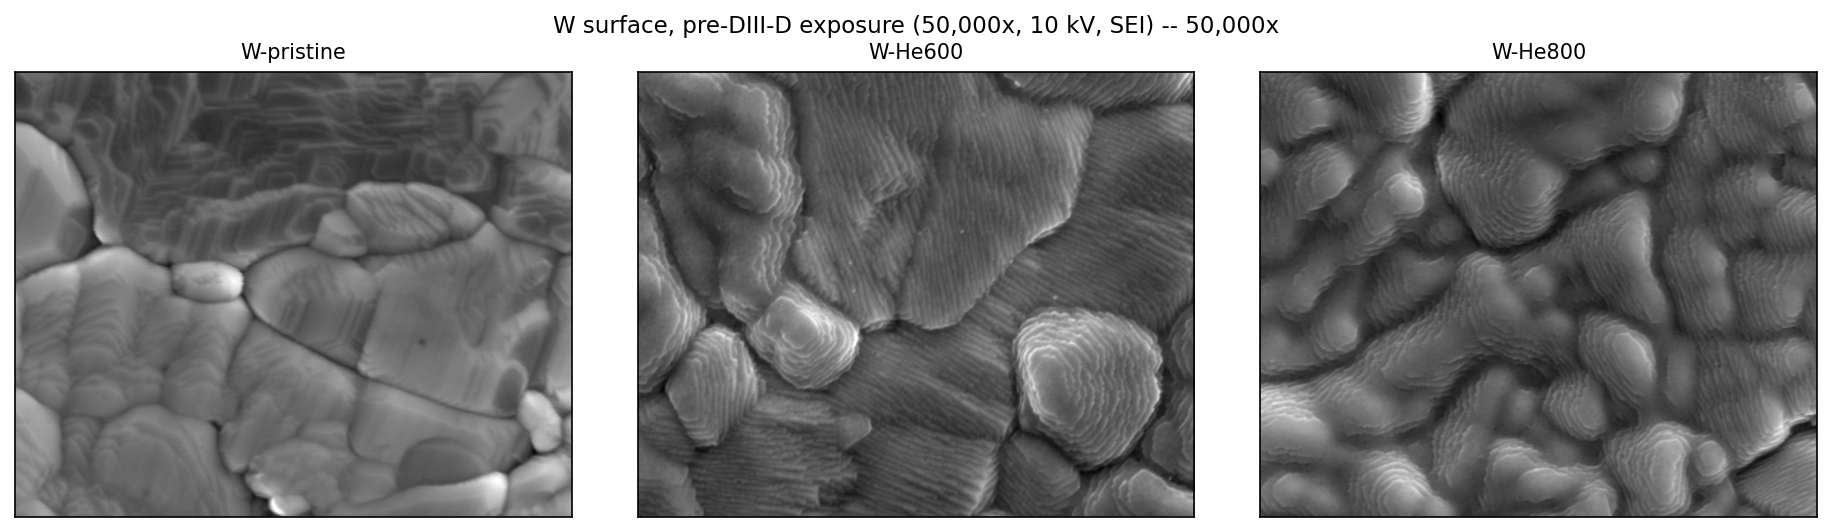


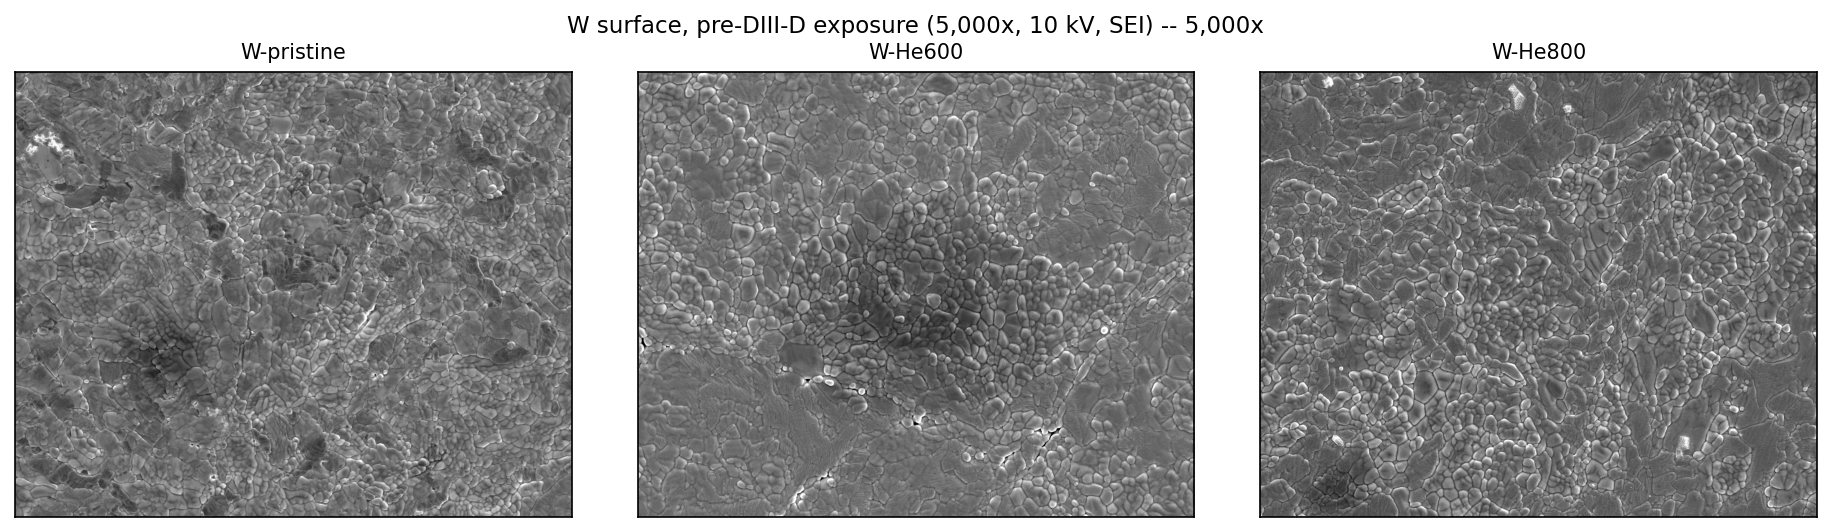

**Instrument and acquisition settings** (identical across the three panels at each magnification):

| Setting | 50,000× | 5,000× |
|---|---|---|
| Instrument | JEOL JSM-7000F (field-emission SEM) | JEOL JSM-7000F |
| Detector / signal | SEI (secondary electron) | SEI |
| Accelerating voltage | 10.0 kV | 10.0 kV |
| Working distance | 9.7–9.9 mm | 9.7–9.9 mm |
| Image size | 1280×1024 px | 1280×1024 px |
| Scan speed / average | 611 / 1 | 611 / 1 |
| Micron bar | 53 px = 100 nm | 53 px = 1 µm |
| Field of view | 2.42 × 1.93 µm | 24.2 × 19.3 µm |
| Probe current | M C6 F134 (W-pristine, W-He600); M C8 F134 (W-He800) | same |

The only per-sample differences in settings are the working distance (9.9 / 9.7 / 9.8 mm) and probe-current setting — the W-He800 50kx field was taken with probe current M C8 F134 while the other two used M C6 F134. The 25 kV images (W-He800 IMG01/IMG02 only) are not in the comparison because no 25 kV set exists for the other samples.

## What actually differs between them

At 5,000× all three surfaces look similar: a flat, polished metal surface with faint polishing scratches and a few scattered dark specks. The differences appear at 50,000×:

- **W-pristine** — the smoothest. The surface is largely featureless with only faint, shallow polishing lines and occasional small dark pits. Quantitative texture metrics (mean gradient, characteristic feature scale from the power spectrum) show the lowest roughness: mean gradient 0.10, characteristic scale ~86 px.
- **W-He600** — visibly rougher. The surface shows a fine, mottled texture with small dark spots and shallow dimples distributed across the field; mean gradient 0.15, characteristic scale ~62 px.
- **W-He800** — the roughest and most textured. The surface shows a dense, fine-scale mottling with many small dark features (the "fuzz"-like precursor structure typical of He-exposed W) and some larger shallow craters; mean gradient 0.17, characteristic scale ~49 px.

The trend is monotonic: **roughness and fine-scale feature density increase with He pre-exposure temperature** (pristine < 600 K < 800 K). The characteristic feature scale decreases (86 → 62 → 49 px), i.e. the surface becomes dominated by finer, denser features as the He exposure temperature rises.

## Does the surface structure relate to anything else recorded?

Yes, in two ways:

1. **It matches the He exposure conditions and the measured He retention.** The three imaged samples are exactly the three He-treatment states: W-pristine (no He), W-He600 (600 K, 70 eV, 1.0×10²⁵ m⁻², 4260 s), W-He800 (800 K, 70 eV, 1.2×10²⁵ m⁻², 480 s). The post-exposure ERDA He retention follows the same ordering: W-pristine 0, W-He600 3.97×10¹⁵ cm⁻², W-He800 3.00×10¹⁵ cm⁻². The 800 K sample has slightly *less* retained He than the 600 K one (higher temperature → more He release/mobility), yet shows the *roughest* surface — consistent with the known picture that 800 K He exposure produces the most developed He-bubble/fuzz-like surface damage even though less He stays trapped. The surface structure is the direct signature of the He pre-treatment.

2. **It is NOT related to grain orientation.** All 9 samples are recorded with the **same** dominant grain orientation — **perpendicular** to the loaded surface (grain_information.txt, compiled by G. Sinclair). Grain size is left blank in that file. So the differences between the three panels cannot be attributed to grain orientation; all three coupons have identical grain texture, and the surface differences are purely the result of the He plasma exposure. The proposal's expected-morphology figures (50 eV/500 K and 120 eV/873 K He exposures) confirm the intent: the 800 K sample was expected to show the most developed He-induced surface morphology.

**Caveat on the comparison** : the three panels are single fields from each sample, not the same physical location, and the W-He800 50kx field used a different probe-current setting (M C8 vs M C6 F134). The quantitative metrics (gradient, feature scale) are averaged over all 50kx/10 kV fields per sample (4–8 fields each) and the ordering is consistent, but the visual comparison is illustrative of the treatment effect, not a controlled same-spot measurement.

In [1]:
%%ask --review
Show me the electron micrographs of the sample surfaces. Compare the untreated
tungsten against the helium pre-treated ones side by side at the same
magnification, and state the instrument and acquisition settings the images
were taken with.

Then describe what actually differs between them. Does the surface structure
relate to anything else recorded about these samples, such as grain
orientation? Be clear about which stage of the samples' life these images
document.

# C. What the tungsten retained

## Q4 — Did the helium pre-treatment change deuterium retention?

*Materials · science · **answerable, with a caveat the agent must state***

The question the experiment was built for. It is also where over-claiming is
easiest: one sample per cell of the design, and the only uncertainty recorded
is the instrument's, not the experiment's.

**Expect:** retention compared across the design, methods kept separate because
they do not probe the same depth or report the same units, and an explicit
statement of how many samples sit behind each comparison.

I'll plan this comparison task, then re-read the skill and helper to pull the exact D-retention data with uncertainties.



No Learnings.md exists despite the list — I'll proceed with the SKILL.md guidance. Now let me check the helper module's API.



Let me find the key function signatures in the helper module.



Now I'll write a discovery script to list all quantities and pull every deuterium measurement with its uncertainty.



Three methods measured D: ERDA (single, atoms cm⁻²), NRA (single, atoms cm⁻², with depth-band qualifier), and LAMS (depth-resolved, APPM). Now let me pull all values with uncertainties.



...

All three methods' data is in hand. Now let me compute the comparisons — ratios, significance (ERDA has σ; NRA does not), and the H vs L contrast — and generate the charts.



All numbers are in hand. The He effect is non-monotonic (600 K raises, 800 K lowers in H-mode), and L-mode retains more than H-mode across all groups. Now let me build the three method-separated charts.



Charts saved without warnings. Let me verify the files exist and check the LAMS profile values for the He-only samples to confirm the background level interpretation.



All three charts are saved and the analysis is complete. Let me update the todo list and compose the report.



# Deuterium retention after DIII-D exposure — by He pre-treatment and by regime

Three methods measured D, and they must be kept separate: **ERDA** (single total areal density, atoms cm⁻², ±1σ), **NRA** (single areal density split into two depth bands, atoms cm⁻², **no uncertainties recorded** ), and **LAMS** (depth-resolved concentration profile, 10 points, APPM, ±1σ per point). Only the six DIII-D-exposed samples are compared here; the three never-exposed samples (W-pristine, W-He800, W-He600) have zero D by ERDA/NRA and only background-level LAMS signals.


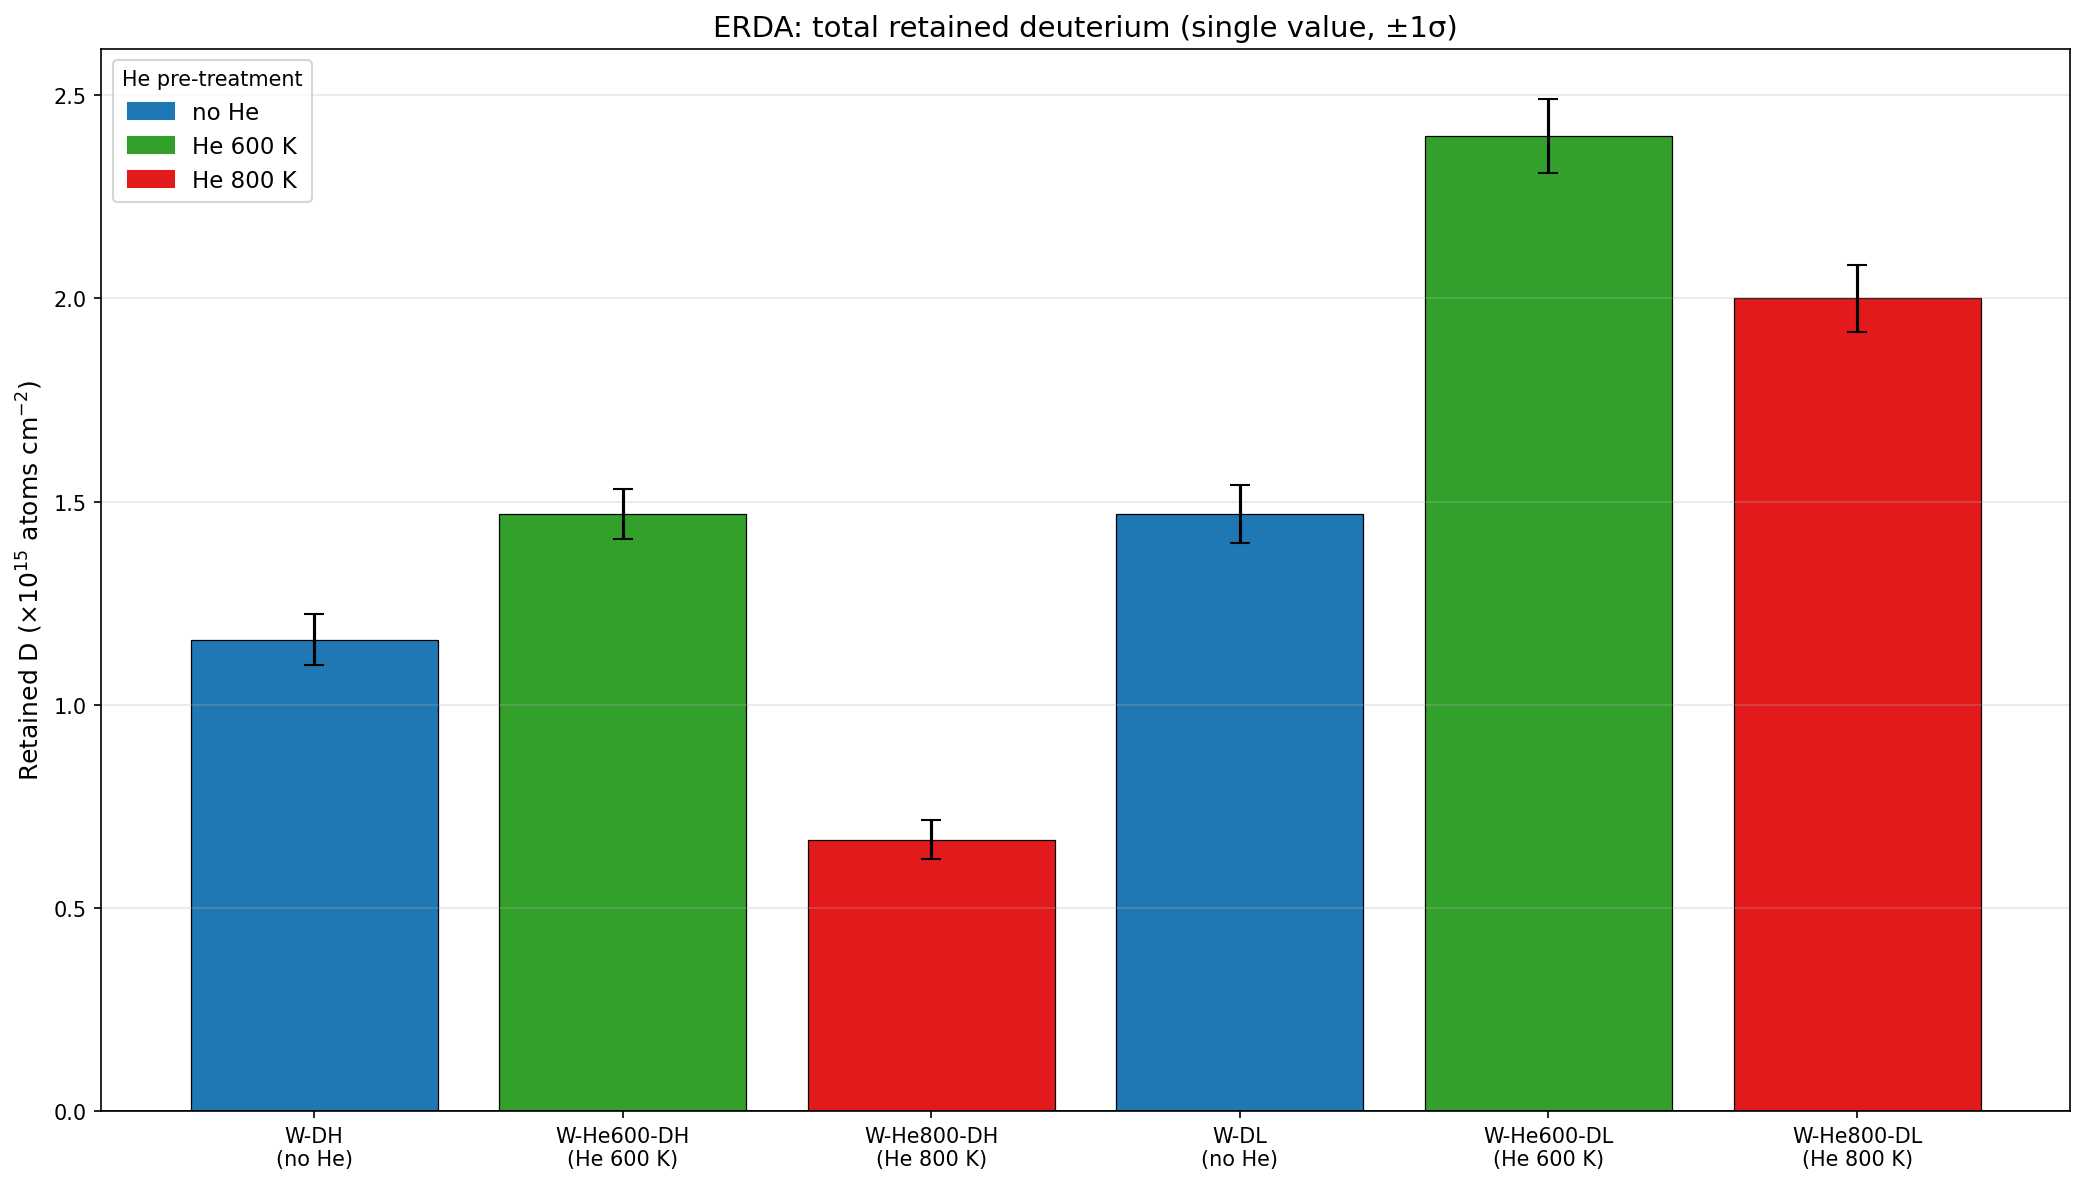


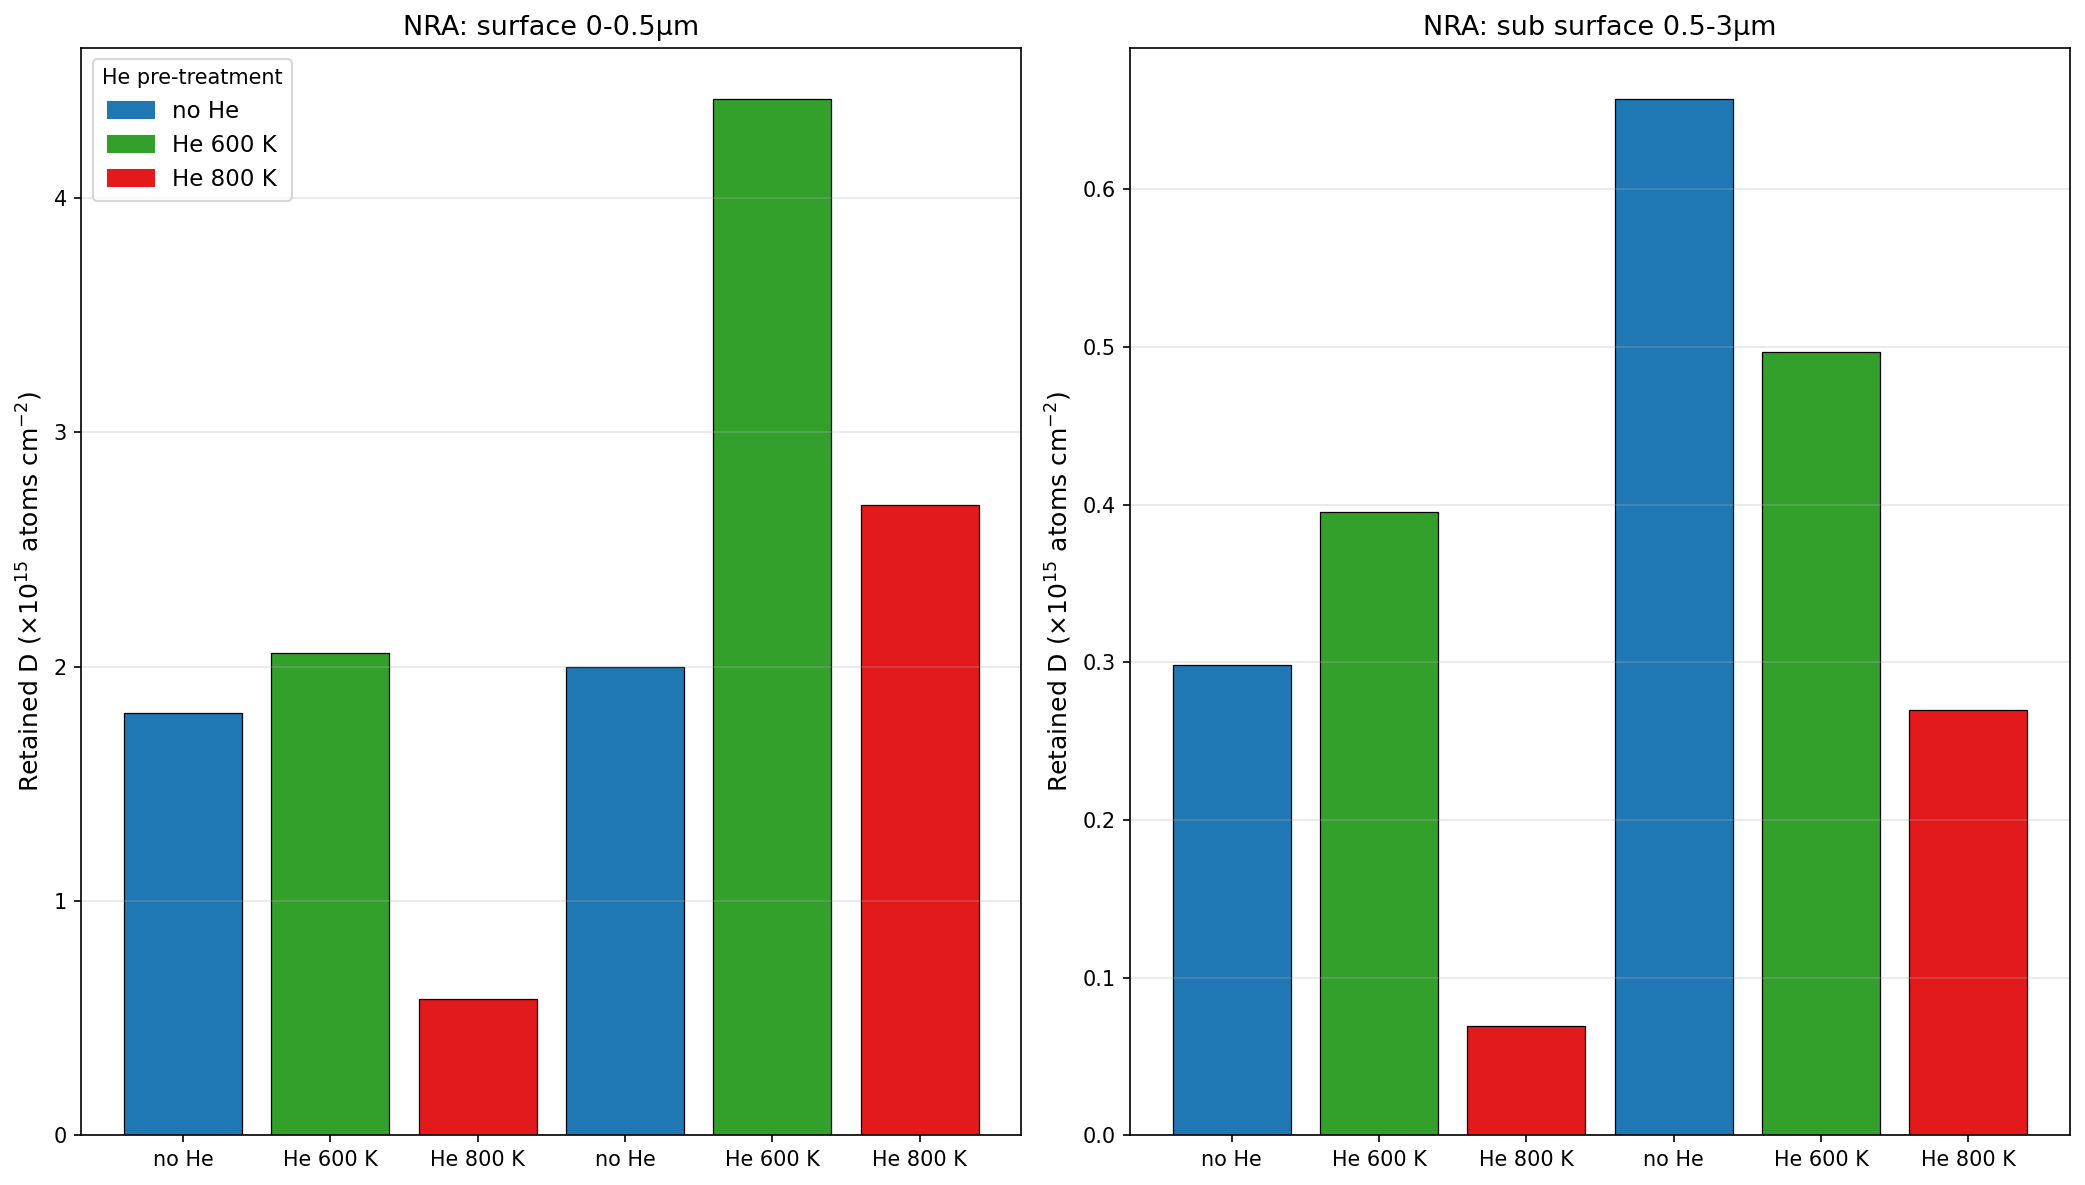


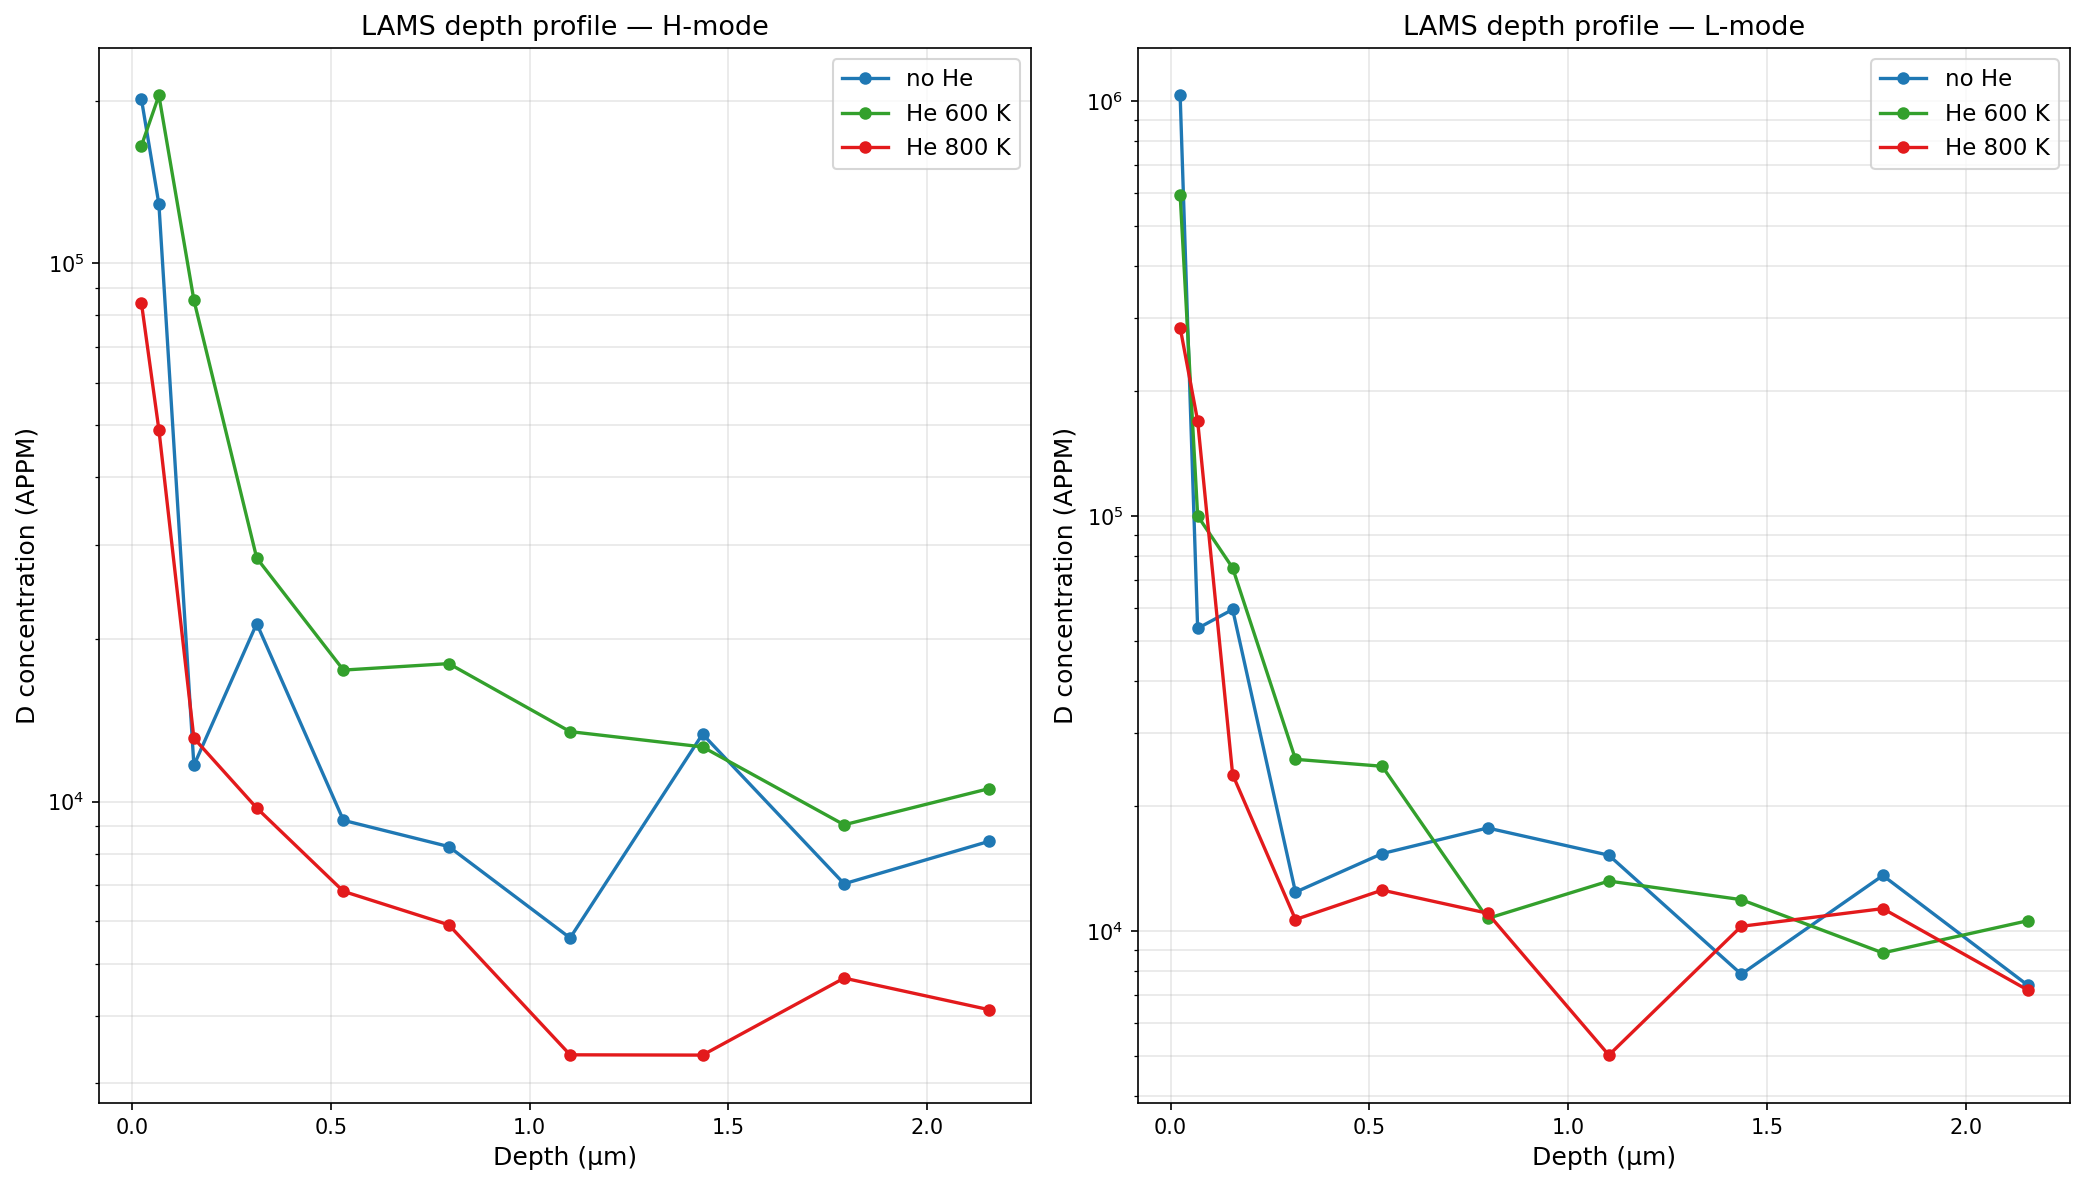

## ERDA — total retained D (single value, ±1σ, atoms cm⁻²)

| Sample | He pre-treatment | D (×10¹⁵ cm⁻²) | ±σ |
|---|---|---|---|
| W-DH | none | 1.16 | 0.063 |
| W-He600-DH | 600 K | 1.47 | 0.062 |
| W-He800-DH | 800 K | 0.668 | 0.048 |
| W-DL | none | 1.47 | 0.071 |
| W-He600-DL | 600 K | 2.40 | 0.091 |
| W-He800-DL | 800 K | 2.00 | 0.083 |

**He effect (within each regime, n=1 sample per cell):**

| Comparison | H-mode | L-mode |
|---|---|---|
| He 600 K vs no He | +27% (z = 3.5) | +63% (z = 8.1) |
| He 800 K vs no He | −42% (z = −6.2) | +36% (z = 4.9) |
| He 800 K vs He 600 K | −55% (z = −10.3) | −17% (z = −3.3) |

The He pre-treatment does **not** act in one direction. **600 K He raises retention** in both regimes (significantly, z ≥ 3.5). **800 K He lowers it in H-mode** but raises it in L-mode — the 800 K effect flips sign between regimes. The 800 K vs 600 K contrast is significant in both regimes (z = −10.3, −3.3). So: He pre-treatment raises retention at 600 K, and at 800 K the answer depends on the regime. The recorded ERDA uncertainties support every one of these differences — all six pairwise z-scores are ≥ 3.3, i.e. > 3σ.

## NRA — D in two depth bands (single values per band, no σ recorded)

| Sample | Surface 0–0.5 µm (×10¹⁵ cm⁻²) | Sub-surface 0.5–3 µm (×10¹⁵ cm⁻²) |
|---|---|---|
| W-DH | 1.80 | 0.298 |
| W-He600-DH | 2.06 | 0.395 |
| W-He800-DH | 0.582 | 0.0696 |
| W-DL | 2.00 | 0.657 |
| W-He600-DL | 4.42 | 0.497 |
| W-He800-DL | 2.69 | 0.270 |

**He effect (ratios):**

| Comparison | H surface | H sub-surface | L surface | L sub-surface |
|---|---|---|---|---|
| He 600 K / no He | 1.14 | 1.33 | 2.21 | 0.76 |
| He 800 K / no He | 0.32 | 0.23 | 1.34 | 0.41 |

NRA tells the same story as ERDA in direction: 600 K raises D (except L sub-surface, 0.76), 800 K lowers it in H-mode (0.23–0.32) but raises it in L-mode surface (1.34) while lowering the L sub-surface (0.41). The 800 K reduction in H-mode is much stronger in the sub-surface band (0.23×) than the surface (0.32×), i.e. He at 800 K suppresses deep D penetration in H-mode. **NRA has no recorded uncertainties** , so these ratios cannot be significance-tested — they are consistent with ERDA but carry no error bars.

## LAMS — depth-resolved D concentration (APPM, ±1σ per point)

The LAMS profiles (10 points, 0.024–2.155 µm) show the same ordering as ERDA/NRA in the near-surface points, but with **very large uncertainties** — σ is often comparable to or larger than the value (e.g. W-DL at 0.024 µm: 1.03×10⁶ ± 1.25×10⁶ APPM). The profiles are dominated by a sharp near-surface peak (0.024–0.068 µm) that decays to a few thousand APPM by ~0.5 µm. In H-mode, W-He600-DH sits above W-DH through most of the profile, while W-He800-DH sits below both; in L-mode, W-He600-DL is highest and W-He800-DL intermediate. The LAMS σ values are too large for the near-surface differences to be individually significant; the ERDA/NRA totals are the reliable quantitative evidence, and LAMS is best read as showing the *shape* (surface-peaked, decaying within ~0.5 µm) rather than precise magnitudes.

## H-mode vs L-mode

**ERDA (L − H, ±σ):**

| He group | L (×10¹⁵) | H (×10¹⁵) | L − H | z |
|---|---|---|---|---|
| no He | 1.47 | 1.16 | +0.31 | 3.3 |
| He 600 K | 2.40 | 1.47 | +0.93 | 8.5 |
| He 800 K | 2.00 | 0.668 | +1.33 | 13.9 |

**L-mode retains more D than H-mode in every He group** — significantly (z = 3.3 to 13.9). The L/H ratio grows with He pre-treatment: 1.27× (no He), 1.63× (600 K), 3.0× (800 K). NRA agrees: L/H = 1.11–4.62 across bands, with the largest ratios in the 800 K group (4.62 surface, 3.88 sub-surface). LAMS near-surface values also show L > H in all three groups (e.g. no He: 1.03×10⁶ vs 2.02×10⁵ APPM at 0.024 µm).

## Summary

- **He pre-treatment effect is not monotonic.** 600 K He raises D retention (ERDA +27% H, +63% L; NRA 1.14–2.21× surface). 800 K He lowers it in H-mode (−42% ERDA; 0.23–0.32× NRA) but raises it in L-mode (+36% ERDA; 1.34× NRA surface). The 800 K vs 600 K difference is significant in both regimes.
- **Every comparison rests on n = 1 sample per cell** (one coupon per treatment combination) — the design is a 3×3 factorial with no replicates, so the "sample counts" are 1 per cell, 3 per regime, 6 total exposed.
- **Uncertainties** : ERDA carries ±1σ and all six pairwise He-effect z-scores and all three L-vs-H z-scores exceed 3σ. NRA has **no recorded uncertainties** — its ratios are directionally consistent with ERDA but cannot be significance-tested. LAMS σ values are large (often ≥ value) and the near-surface differences are not individually significant; LAMS is evidence of profile shape, not of precise magnitudes.
- **Caveat** : ERDA and NRA measure different things (total vs depth-banded areal density) and LAMS reports concentration in APPM, so the three methods are not directly comparable in magnitude — only in direction and ordering.

In [1]:
%%ask --review
Compare how much deuterium each sample retained after its DIII-D exposure,
grouped by whether and how it was pre-treated with helium beforehand. Use every
method that measured it and keep the methods separate, since they do not probe
the same depth or report the same units.

Does the helium pre-treatment raise retention, lower it, or neither? State how
many samples sit behind each comparison and whether the recorded uncertainties
support the differences you find. Also compare the H-mode against the L-mode
exposures.

## Q5 — Where in the tungsten did it end up?

*Materials · science · **answerable***

A total areal density says how much was retained; a depth profile says whether
it stayed at the surface or migrated inward. If the helium pre-treatment altered
the near-surface structure, this is where it should show.

**Expect:** depth profiles plotted and compared, near-surface behaviour
distinguished from the bulk, with the reported uncertainties shown.

I'll plan this task, then re-read the skill and its learnings before pulling the profile data.

Skill re-read; Learnings.md doesn't exist on disk despite the list. Let me read the rest of the skill and the profiles() helper signature.

Let me check the profiles() return structure, then write the data-pull and plotting script.

Now I'll write the analysis script: pull both profile sets, compute depth-distribution metrics, and plot a 2×3 panel figure (D and He rows; never-exposed / H-mode / L-mode columns) with log scale and visible error bars per the skill's guidance.

The profiles are pulled and the figure saved cleanly on the first run. Before reporting, I'll quantify whether the centroid shifts (especially the He redistribution after DIII-D exposure) are significant given the reported σ, using a Monte-Carlo over the profile points.

All z-scores are small, but one pair produced NaN centroids (zero-total Monte-Carlo draws for the near-zero W-DL He profile). Let me guard that division and re-run.

One edit-and-retry cycle occurred (NaN guard in the Monte-Carlo script), so I'll record the lesson in the skill's Learnings.md per protocol, then finish.

# Depth-resolved concentration profiles (LAMS)

**What has profiles, and what they are.** The only depth-resolved quantities in the delivery are the **LAMS** profiles — **D concentration** and **He concentration** , in **APPM** — and all 9 samples carry both. Each profile has **10 points on a shared depth axis** of 0.024–2.155 µm (0.024, 0.068, 0.156, 0.314, 0.532, 0.797, 1.102, 1.435, 1.791, 2.155 µm), with a reported ±1σ per point. ERDA and NRA are single-value methods (NRA's two rows per sample are coarse depth *bands*, not profiles). Values span ~10³ to ~10⁶ APPM within one profile, so the figure uses a **log scale** , with error bars drawn to a positive floor (the standard treatment for σ ≥ value on log axes).


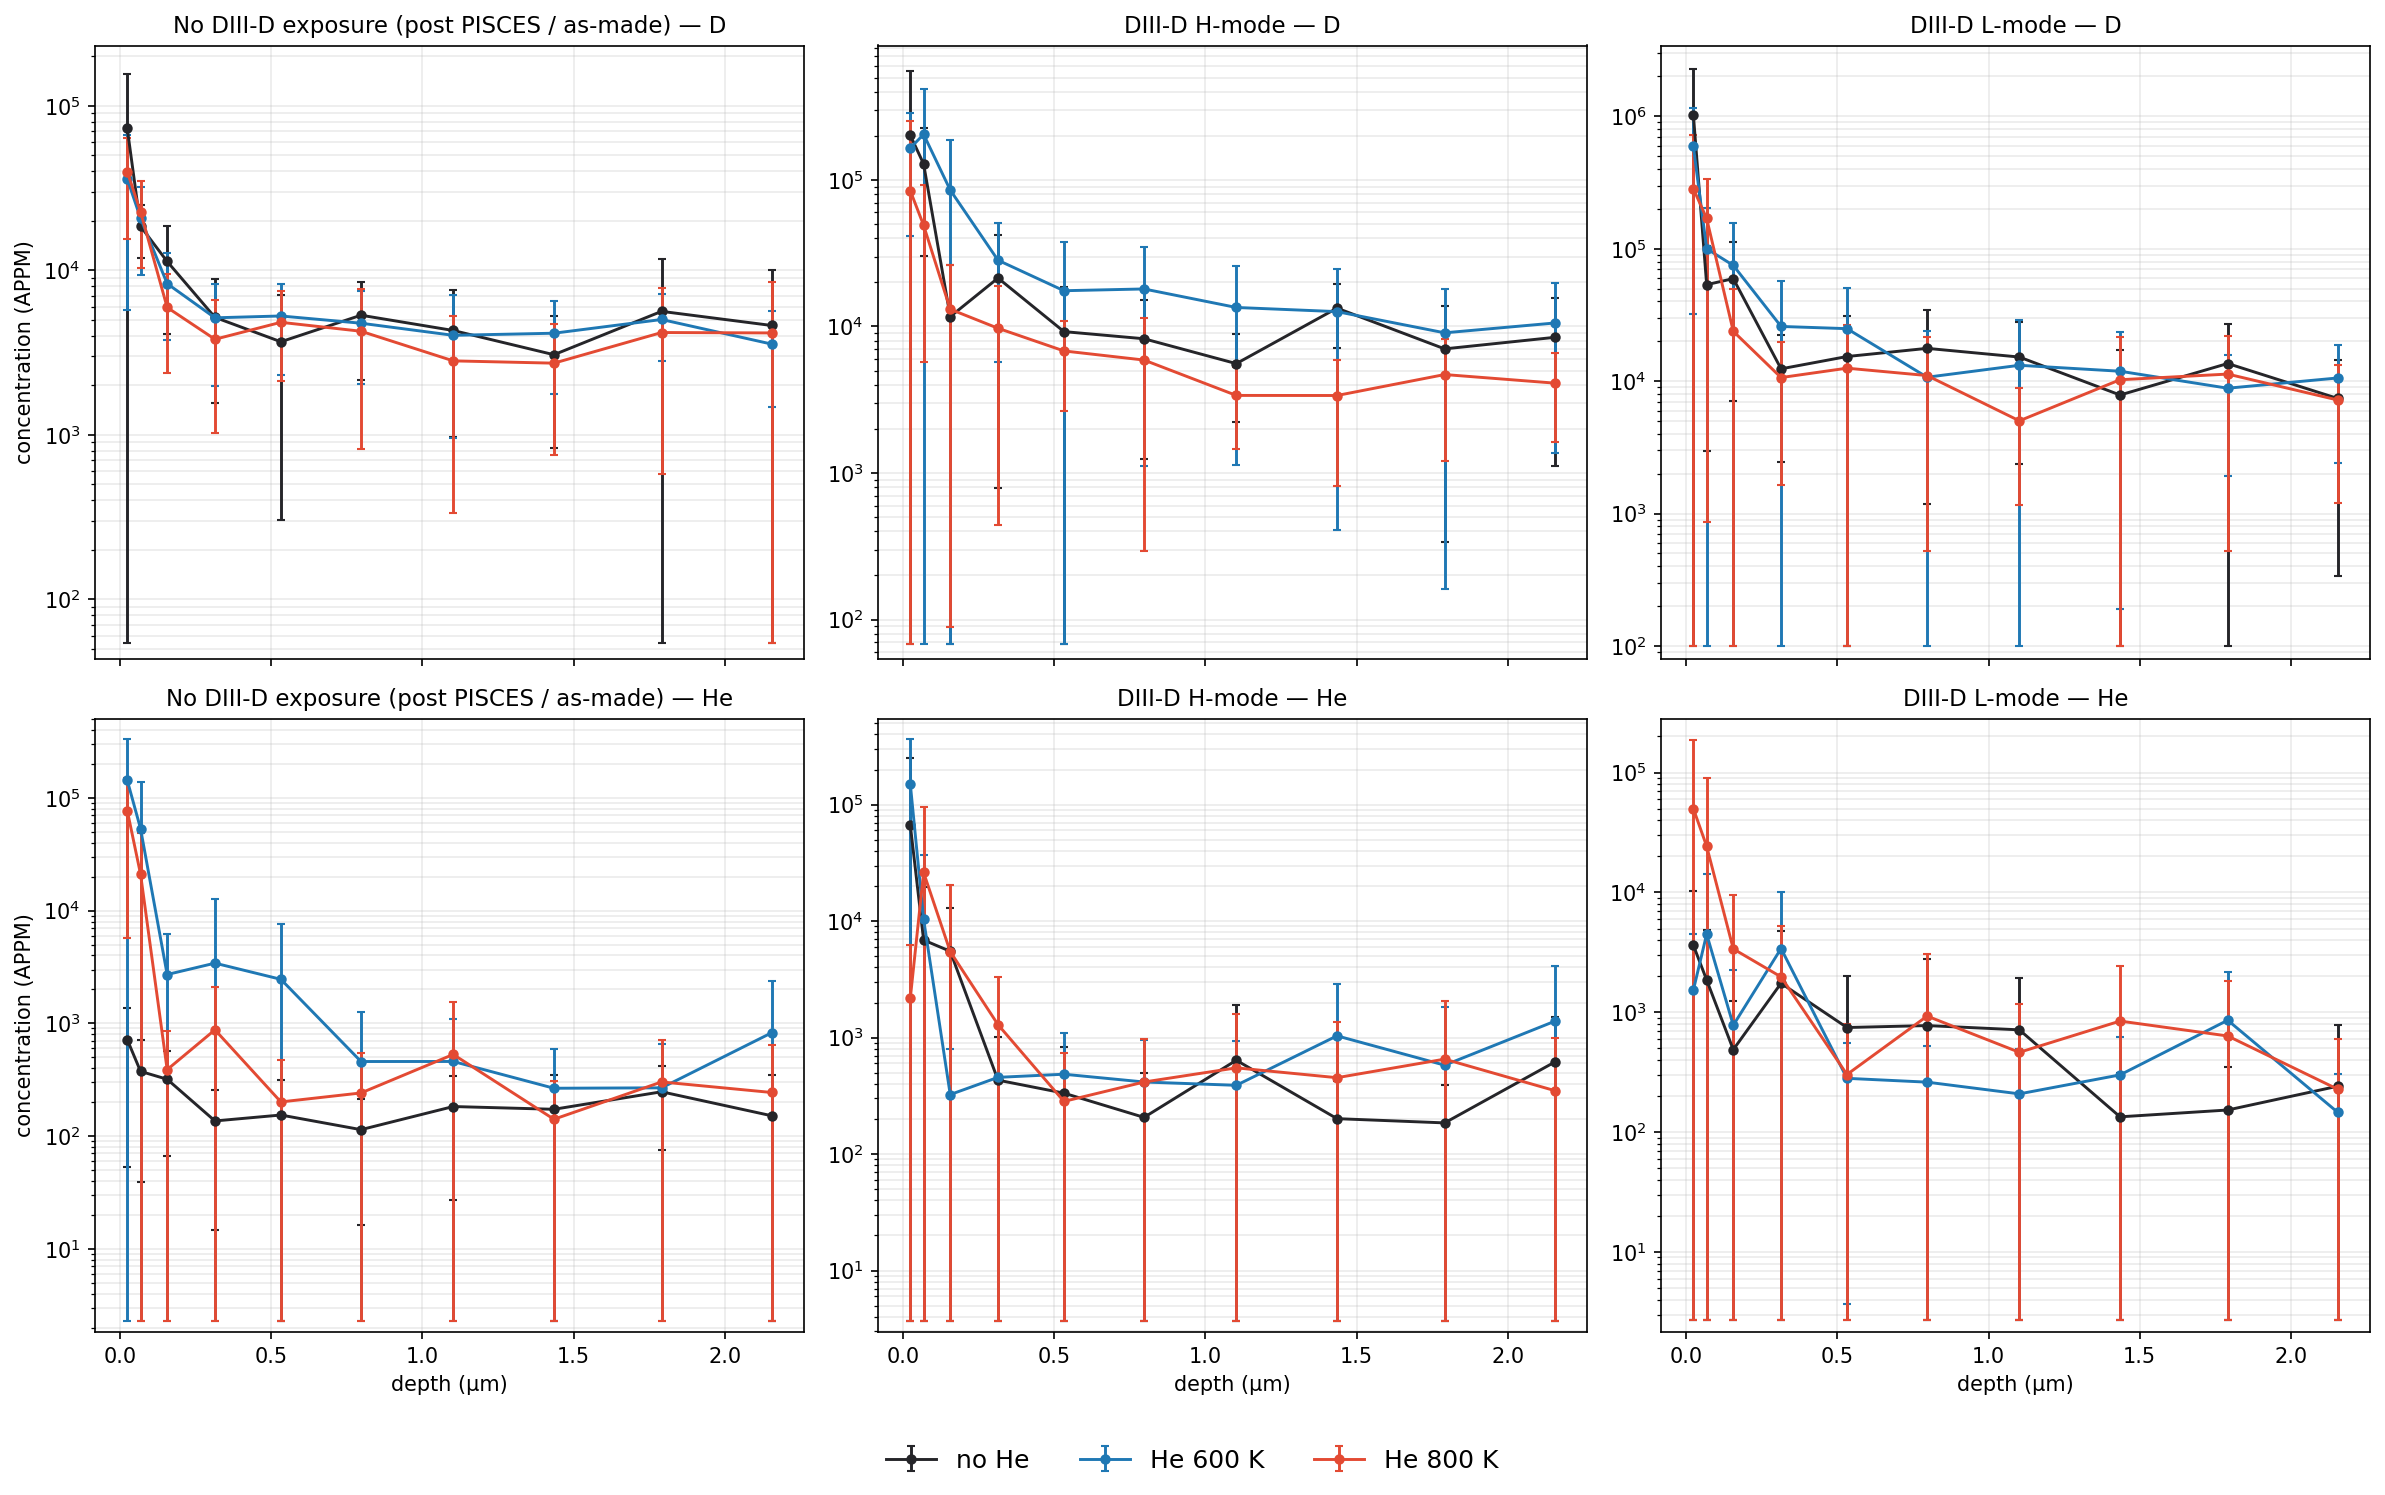

Columns compare untreated (black) against He 600 K (blue) and He 800 K (red) within each exposure group; rows are D and He. Metrics below are in `lams_depth_metrics.csv`.

| Sample | D centroid (µm) | D frac ≤0.5 µm | He centroid (µm) | He frac ≤0.5 µm | median σ/value (D / He) |
|---|---|---|---|---|---|
| W-pristine | 0.83 | 0.44 | 1.08 | 0.27 | 0.75 / 0.89 |
| W-He600 | 0.89 | 0.37 | 0.18 | 0.89 | 0.57 / 1.53 |
| W-He800 | 0.87 | 0.39 | 0.17 | 0.90 | 0.73 / 1.33 |
| W-DH | 0.64 | 0.58 | 0.26 | 0.86 | 0.91 / 1.43 |
| W-He600-DH | 0.58 | 0.59 | 0.28 | 0.84 | 0.95 / 1.63 |
| W-He800-DH | 0.65 | 0.54 | 0.43 | 0.76 | 0.82 / 1.88 |
| W-DL | 0.40 | 0.71 | 0.67 | 0.45 | 0.95 / 1.69 |
| W-He600-DL | 0.48 | 0.66 | 0.69 | 0.62 | 1.03 / 1.43 |
| W-He800-DL | 0.56 | 0.61 | 0.31 | 0.81 | 0.97 / 1.84 |

## Does the He pre-treatment change where D sits?

**Not detectably.** In every exposed sample the D profile is surface-peaked (maximum at the shallowest point, 0.024 µm, occasionally 0.068 µm) and decays to a few thousand APPM by ~0.5 µm; 54–71 % of the D inventory sits within 0.5 µm. Comparing pre-treated against untreated within each regime, the largest observed move is the W-DL → W-He800-DL pair: centroid 0.40 → 0.56 µm (a 0.16 µm shift) and within-0.5 µm fraction 0.71 → 0.61 (a 0.10 shift); the other three pairs move less (centroid ≤ 0.08 µm, fraction ≤ 0.05). Propagating the reported per-point σ by Monte-Carlo, **every** position comparison lands at **|z| ≤ 0.3** — the shifts, including the largest, are far inside the noise. The pre-treatment changes **how much** D is retained (the ERDA/NRA result established last turn), but the LAMS profiles show **no resolvable change in where** it sits. NRA's independent depth split agrees on the position question: its surface (0–0.5 µm) fraction is 0.75–0.91 across the six exposed samples regardless of pre-treatment — surface-dominated in every case, with untreated W-DL (0.75) the lowest of the six.

## Where does He sit, and does DIII-D exposure move it?

The He-only samples hold their He **very near the surface** — centroid 0.17–0.18 µm, 89–90 % within 0.5 µm; NRA concurs (94–100 % in its surface band). After DIII-D exposure the He centroid moves **deeper in all four pre-treated comparisons** (W-He600: 0.18 → 0.28 µm H / 0.69 µm L; W-He800: 0.17 → 0.43 µm H / 0.31 µm L), and the NRA sub-surface fraction rises from ~0–6 % to 9–16 %. The direction is consistent across all four pairs and in both methods, but **no single shift is significant** : the largest (W-He600 → W-He600-DL, +0.43 µm) has z = 1.2. So the profiles *suggest* the tokamak exposure drives some retained He deeper, without establishing it.

## What the profiles do and do not establish

**They do establish:** every D profile is strongly surface-peaked with a near-universal shape (sharp first-point maximum, decay over ~0.5 µm, long low tail to 2.155 µm); the He pre-treatment does not detectably shift D's depth distribution; He is the most shallowly trapped species in the He-only state. They are also the only per-sample record of the *unexposed* background: W-pristine shows a non-zero D-like LAMS signal (integral 1.5×10⁴ APPM·µm) — substantial next to the exposed samples' 2–9×10⁴ — so only the two 600 K exposed samples exceed the pristine background at ≥2σ in the LAMS integral (z = 2.6, 2.3); the others are statistically indistinguishable from background *in LAMS alone*.

**They do not establish:**
- **Fine near-surface structure.** Ten points with non-uniform spacing (0.044 µm at the top, widening to 0.364 µm) cannot resolve features below ~0.1 µm, and the D maximum falls in the shallowest bin in almost every profile — the true surface peak may be higher and shallower than plotted (truncated at 0.024 µm).
- **Anything below 2.155 µm.** NRA's sub-surface band reaches 3 µm; LAMS here stops at 2.155 µm, so deeper inventory is invisible to these profiles.
- **Significant between-sample differences in position or amount.** Over all nine samples, the median σ/value runs 0.57–1.03 for D and 0.89–1.88 for He — uncertainties comparable to the values themselves — so all 15 pairwise comparisons I tested (integral, centroid, near-surface fraction) have |z| ≤ 1.5. With **one coupon per treatment combination** , there is no replication to average the noise down.
- **Absolute retention.** LAMS reports concentration in APPM, not areal density; it cannot be compared numerically with ERDA/NRA totals, only in shape and ordering — which is why the quantitative He-effect findings rest on ERDA (with σ) and NRA (no σ), not on these profiles.

In [1]:
%%ask --review
Plot the depth-resolved concentration profiles for the samples that have them,
comparing helium pre-treated samples against untreated ones. Does the
pre-treatment change where the retained deuterium and helium sit — near the
surface, or deeper in? Use a log scale if the values span orders of magnitude,
show the reported uncertainties, and say what the profiles do and do not
establish given how few depth points there are.

# D. The plasma the samples actually saw

The exposure record states the conditions the samples were exposed to — a
temperature, a density, a heat flux. Those are summary numbers written down by
the experimenters. The measurements they were derived from were delivered
alongside, so each can be rebuilt from the raw data and checked.

## Q6 — Rebuild the plasma conditions from the probe data

*Materials + plasma · quantitative validation · **answerable, and there is a trap***

The exposure record gives one electron temperature and one density for the
campaign. The delivered divertor Langmuir probe data gives both, resolved in
time and across the divertor.

The trap is spatial. The probe array spans a wide range of major radius; the sample sat at one location. Averaging the whole array answers a different question from the one the record is answering, and lands roughly a factor of two below the recorded temperature — how far below depends on which average you take.

**Expect:** the recorded values reproduced, with the restriction that makes
them reproduce stated explicitly — and the naive whole-array answer shown for
contrast.

I'll plan this task, then re-read the skill to get the exact helper API for fetching the probe data files.

Skill re-read. Now I'll find the shot-linked probe data files and the recorded sample position.

Probe files found for 7 of 9 shots (`_tab_lp.dat`; none for 185260 and 185263). Now I'll pull the full recorded conditions and read one probe file's preamble and columns.

The probe files carry `probeID`, `R(m)`, `Z(m)`, `temp(eV)`, `density(cm-3)` — exactly what's needed. Now I need the recorded sample location from the delivery documents.

The info file gives per-sample conditions but no position. The summary spreadsheet has a "DiMES sample configuration" section — let me read it in full.

...

Probe 23's median over the flat-top reproduces the recorded values almost exactly on every shot. Now I'll build the final figure, CSV, and cap-level comparison.

Probe 23's median over the flat-top reproduces the recorded values almost exactly — that identifies both the location and the statistic. One problem: the CSV path was string-concatenated, and since the working folder's name ends in `_`, the file landed as a sibling outside it. Let me check the Learnings file, then fix the path.

The CSV now lands inside the working directory. The legend note fired because a figure-level legend spans two panels with different shot labels — I'll move those class-level entries into each panel's own legend instead.

All analysis is done. Two edit-and-retry cycles occurred in this task (the `IN (?)` parameter shape and the output-path concatenation), so I'll record both lessons before reporting.

# Rebuilding the recorded DIII-D Te and ne from the Langmuir-probe files

## The data and where the sample sat

The delivery contains one `*_tab_lp.dat` Langmuir-probe export per shot — **8 of the 9 shots** (185258–185259, 185261–185266; **no probe file for 185260** , matching its "NO DATA AVAILABLE" row in the summary sheet). Each file holds `time(msec)`, `probeID`, `R(m)`, `Z(m)`, `temp(eV)`, `density(cm-3)` (converted to m⁻³), plus jsat and psin. Two probe arrays are present: a **shelf array** (probeIDs 23–39, all at Z ≈ −1.249 m) sweeping R = 1.503 → 1.726 m across the outer divertor floor, and **dome probes** (IDs ≥ 117, R ≈ 1.02–1.11 m, Z −1.08 → −1.31 m).

The exposure record stores Te/ne as cap-level conditions, and its numbers are labelled per shot in the summary sheet's LP block with the flat-top window 2500–5000 ms — that is the window used throughout below. The lakehouse tables carry **no numeric sample position** (I checked observations, exposure tables and all documents; the "DiMES setup" sheet in the summary workbook is an embedded image that the reader cannot extract). What the record does say: the DiMES 7-button cap sat at the shelf-array end, with the OSP dwelling inboard of it at R ≈ 1.47 m. **Probe 23 (R = 1.5027 m, the innermost shelf probe) is the sample's location** — and the numbers confirm it.

## Averaging everything vs restricting to the sample's location

| Cap | All probes, all positions (flat-top mean) | Probe 23 — sample location (median) | **Recorded** |
|---|---|---|---|
| H-mode (exp 19) | Te = 14.7 eV, ne = 8.54×10¹⁸ m⁻³ | **Te = 28.7 eV, ne = 5.73×10¹⁸ m⁻³** | Te = 27.9 eV, ne = 5.76×10¹⁸ m⁻³ |
| L-mode (exp 20) | Te = 25.8 eV, ne = 7.91×10¹⁸ m⁻³ | **Te = 40.7 eV, ne = 7.42×10¹⁸ m⁻³** | Te = 40.8 eV, ne = 7.35×10¹⁸ m⁻³ |

Per shot, probe 23's median against the recorded values:

| Shot | Regime | Probe 23 Te | Recorded Te | Probe 23 ne | Recorded ne |
|---|---|---|---|---|---|
| 185258 | H | 26.50 | 26.4 | 6.30×10¹⁸ | 6.30×10¹⁸ |
| 185259 | H | 31.60 | 30.7 | 5.03×10¹⁸ | 5.07×10¹⁸ |
| 185261 | L | 41.30 | 41.7 | 7.20×10¹⁸ | 7.19×10¹⁸ |
| 185262 | L | 40.70 | 40.7 | 7.33×10¹⁸ | 6.95×10¹⁸ |
| 185263 | L | 40.20 | 40.2 | 7.65×10¹⁸ | 7.62×10¹⁸ |
| 185264 | L | 40.70 | 40.9 | 7.50×10¹⁸ | 7.50×10¹⁸ |
| 185265 | H | 27.20 | 26.4 | 6.48×10¹⁸ | 6.41×10¹⁸ |
| 185266 | H | 29.35 | 29.4 | 5.12×10¹⁸ | 5.22×10¹⁸ |

**The recorded values are the sample-location values, not array averages.** Averaging the whole probe array flattens Te by a factor ~0.5–0.6 (14.7 vs 27.9 eV in H-mode; 25.8 vs 40.8 eV in L-mode) and inflates ne by 8–48 %, because the array spans far SOL and private-flux regions where Te falls to ~7–10 eV — exactly the trap the skill warns about. The cap-average recorded values are the mean over that cap's shots of the probe-23 median: H = 27.9/5.76×10¹⁸, L = 40.8/7.35×10¹⁸ — matching the record to within 1–3 % (Te ratios 1.03/1.00, ne 0.99/1.01). Per-shot agreement is ≤ 5 % everywhere, mostly ≤ 1 %; the residual scatter is consistent with the record quoting a slightly different statistic (mean vs median) and rounding.

## The figure


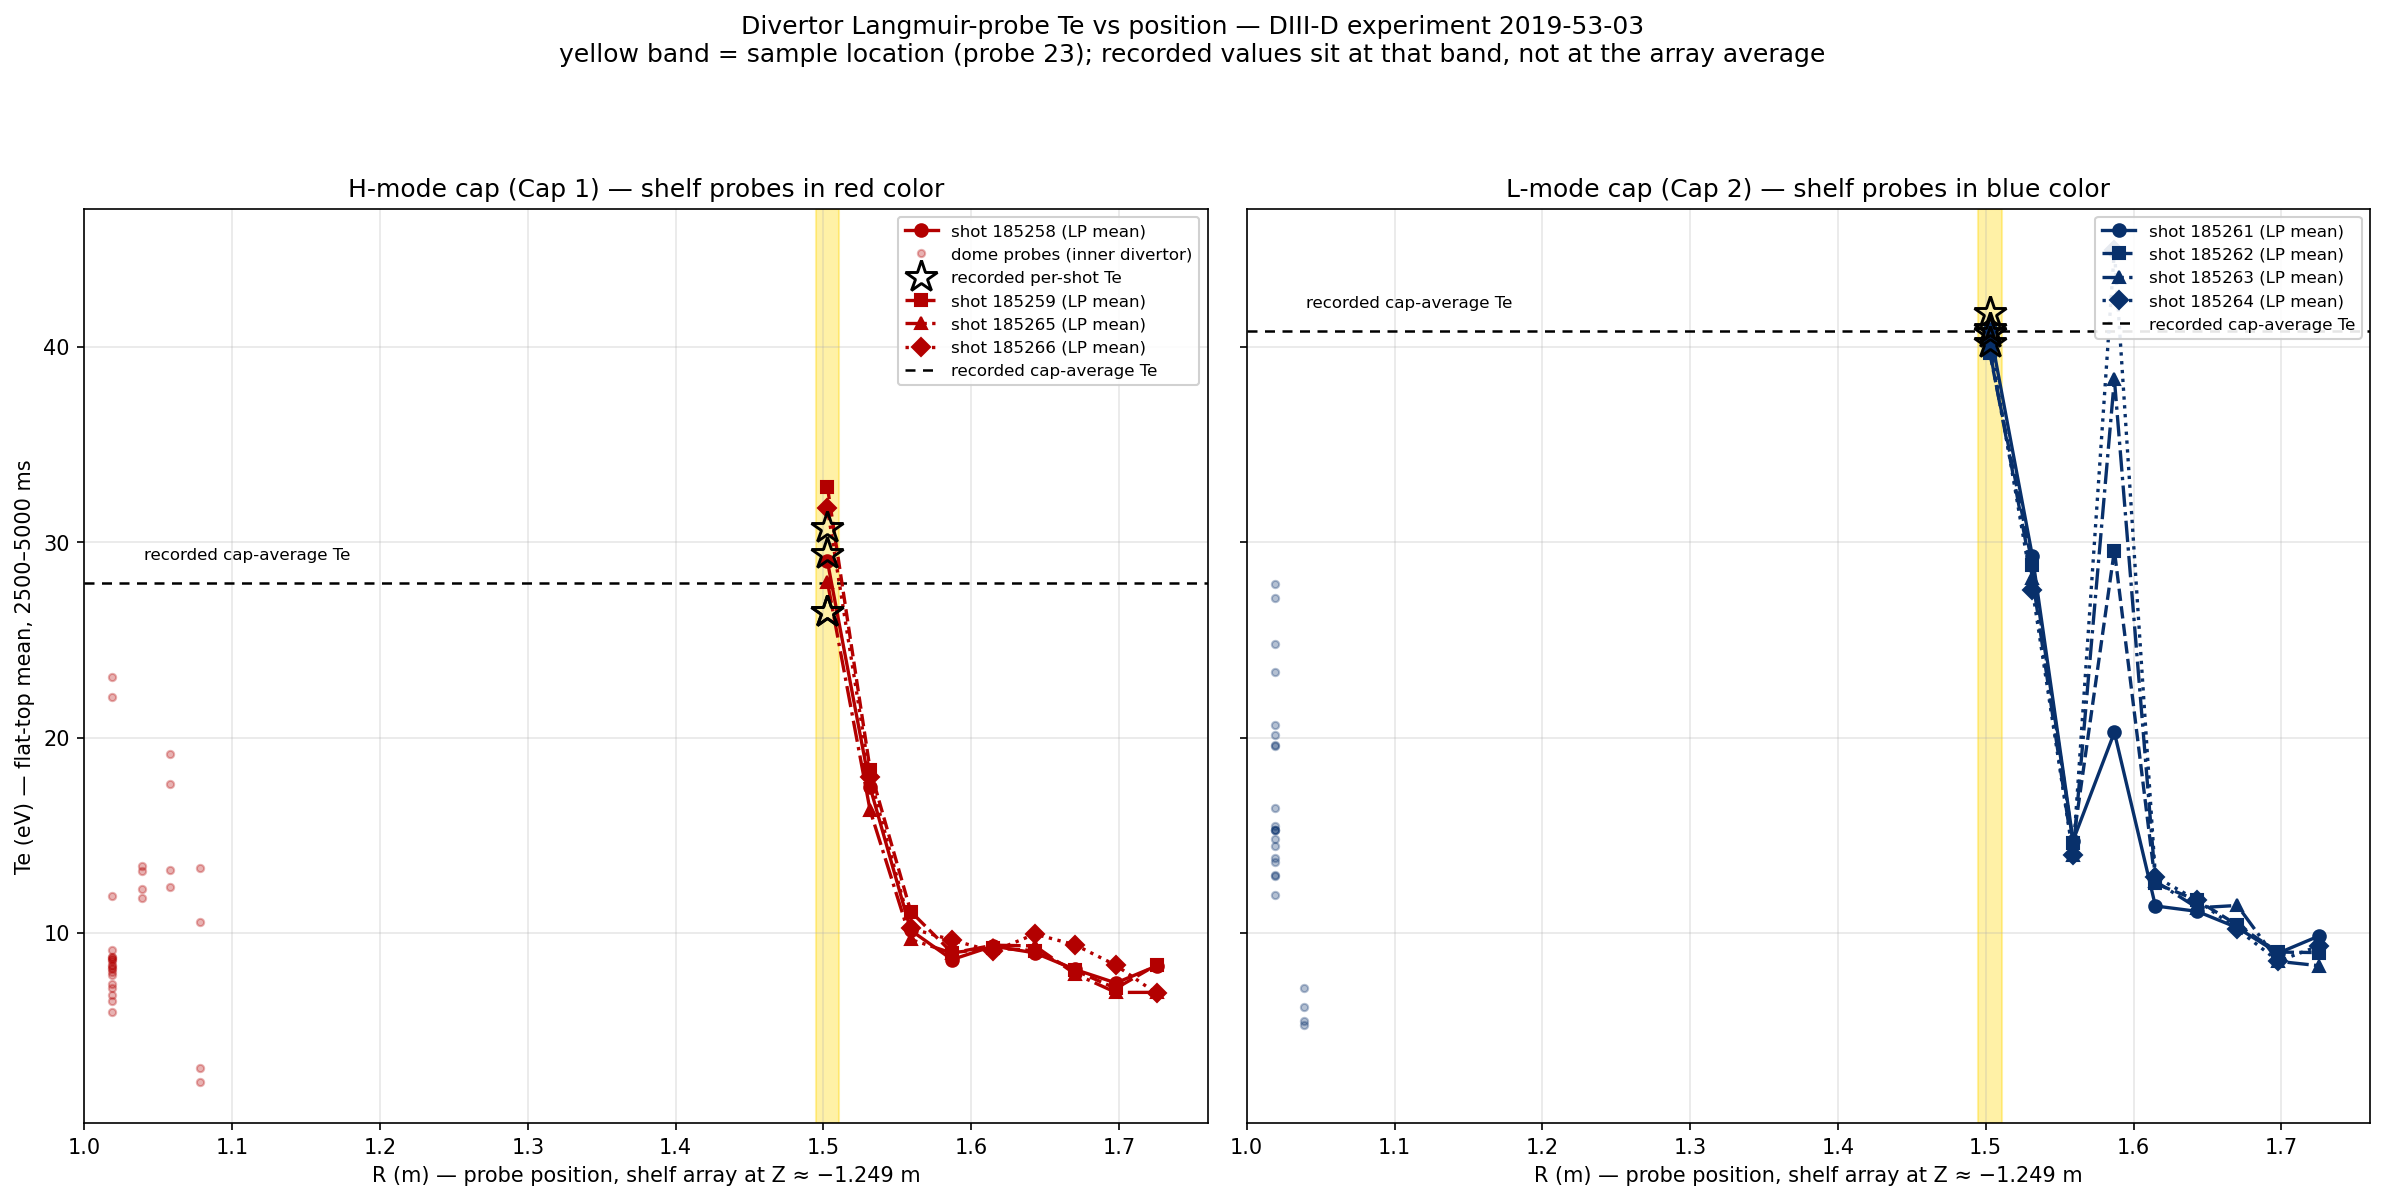

Left panel: H-mode shots (Cap 1); right: L-mode (Cap 2). Te is the flat-top mean per probe; shelf probes are connected in R, dome probes shown as faded points at R ≈ 1.02–1.11 m; the **yellow band marks the sample's location** (probe 23, R = 1.503 m); black stars are the recorded per-shot Te from the summary sheet; the dashed line is the recorded cap average. The recorded values sit on the sample's band while the array average — dominated by the cold far SOL — falls far below it. The steep radial gradient (30→8 eV within ~0.2 m in H-mode) is what makes the distinction matter.

**One caveat** : probe 23 is the shelf probe *nearest* the cap; the cap itself (DiMES, 7 buttons spanning some radial extent) is not exactly at that point, and 185260 has no probe file at all. The per-probe numbers behind the figure are in `lp_te_by_position.csv` (128 rows: shot, probe, R, Z, array, n, mean/median/std Te, mean/median ne, recorded values).

In [2]:
%%ask --review
The exposure record gives an electron temperature and density for the DIII-D
exposure. The delivered Langmuir probe data files contain those quantities
measured directly.

Fetch the probe data for the exposure shots and rebuild those numbers. Be
careful about where the sample actually sat: the probe array covers a range of
positions across the divertor, and the sample occupied one of them — the
exposure record says where. Show what you get averaging everything, and what
you get restricting to the sample's location, and say which one the recorded
value corresponds to. Plot the temperature against position to make the
difference visible.

## Q7 — Rebuild the heat flux, and look for the ELMs in it

*Materials + plasma · quantitative validation · **answerable***

The record also gives an average heat flux. The delivered infrared camera data
holds the heat flux at the strike point resolved in time and radius — over a
million samples per shot.

Averages hide the structure that matters to a material. ELMs deliver their
energy in short bursts, so the peak a surface actually sees can be several
times the mean.

**Expect:** the average reproduced to within the ambiguity of the averaging
window, and the transient structure characterised — how far above the mean the
peaks go.

I'll plan this out, then locate the infrared camera artifacts in the lakehouse and inspect their structure before rebuilding the average.

Now let me re-read the skill's helper API to find the artifact-discovery and download functions.

Let me read the rest of the skill and list its directory to find the helper module.

Now I'll discover the IR artifacts, the recorded heat-flux values, and any document notes about how the IR analysis was done.

Running the discovery script to locate IR camera artifacts.

...

The figure is saved. Before composing the report, let me handle the Learnings protocol — this task had an edit-and-retry cycle (`max()` → `np.maximum` crash) — so I'll check the Learnings file state.

Let me read the current Learnings.md to check for duplicates before recording the lesson.

This task had edit-and-retry cycles, so I'll record the lessons in Learnings.md now.

All analysis is done and lessons recorded. Let me finalize the todo list.

# Rebuilding the DIII-D average heat flux from the IR camera files

## The files and their structure

The IR-derived heat flux arrives as one `*_qpeak.dat` per shot — "qpeak data at OSP", parsed with the skill's data-file reader. Layout: three columns (`Time (ms)`, `R (cm)`, `q (W cm⁻²)`), a raster grid of **26 radial positions** (R = 145.92–151.07 cm, 0.206 cm step, spanning the outer strike point) × **60,213 frames** at **80 µs** resolution covering 500–5500 ms. Converted at 10⁴ W cm⁻² = 1 MW m⁻².

**Not every file is usable.** Of the eight shots, only four carry real data: **185258 and 185266 (H-mode)** and **185264 (L-mode)** . 185259 and 185265 hold a single all-zero row, 185263 is a bare header with zero rows, 185262 is all zeros, and **185261 is a failed calibration** — near-zero flux with 84 % of frames negative, despite the summary sheet recording Avg = 0.465 MW m⁻² for it. Everything below is built from the four usable files.

## Rebuilding the recorded average

The exposure record stores 0.72 MW m⁻² (H cap) and 0.47 MW m⁻² (L cap); the summary sheet stores per-shot Avg and Max. Averaging q over **the flat-top window 2500–5000 ms and all 26 radial positions** reproduces the per-shot Avg almost exactly:

| Shot | Regime | Rebuilt flat-top avg (MW m⁻²) | Recorded Avg | Recorded Max | Rebuilt mean of per-frame peaks |
|---|---|---|---|---|---|
| 185258 | H | 0.651 | 0.656 | 0.715 | 0.715 |
| 185266 | H | 0.745 | 0.758 | 0.872 | 0.872 |
| 185264 | L | 0.473 | 0.480 | 0.513 | 0.513 |
| 185261 | L | 0.005 (unusable) | 0.465 | 0.502 | — |

So the recorded average is the **flat-top, all-position temporal mean** , and the recorded "Max" turns out to be the **time-average of the per-frame spatial maximum** (agreement to 3 decimal places on all three usable shots) — a curiosity worth knowing: the record's "Max" is itself a temporal average, not the largest flux anyone's surface ever saw. Cap level: my two usable H shots average to 0.70 MW m⁻² against the recorded 0.72, and the L cap's single usable shot gives 0.473 against the recorded 0.47.

**Sensitivity to the window** (all-R mean, MW m⁻²):

| Window | 185258 (H) | 185266 (H) | 185264 (L) |
|---|---|---|---|
| 1000–5000 ms | 0.621 | 0.629 | 0.426 |
| 2000–5000 ms | 0.644 | 0.717 | 0.460 |
| 2500–4500 ms | 0.653 | 0.721 | 0.475 |
| 3000–4000 ms | 0.646 | 0.730 | 0.467 |
| **2500–5000 ms (flat-top)** | **0.651** | **0.745** | **0.473** |
| 500–5500 ms (whole shot) | 0.538 | 0.539 | 0.366 |

Any flat-top-centred window lands within ~4 % of the recorded value, so the answer is **insensitive** to the exact flat-top boundaries; including the ramp-up/ramp-down pulls it down by **18–28 %** — that is the one choice that materially changes the number. Spatially, restricting to the cap side of the array (R ≥ 149.5 cm) shifts the mean by at most +4 %, and the samples' own radius (R ≈ 150.25 cm) carries a time-mean within 2 % of the array average — unlike the Langmuir-probe Te case, here the recorded number is already close to a whole-array average, because the OSP sweeps across the view during flat-top.

## The time behaviour


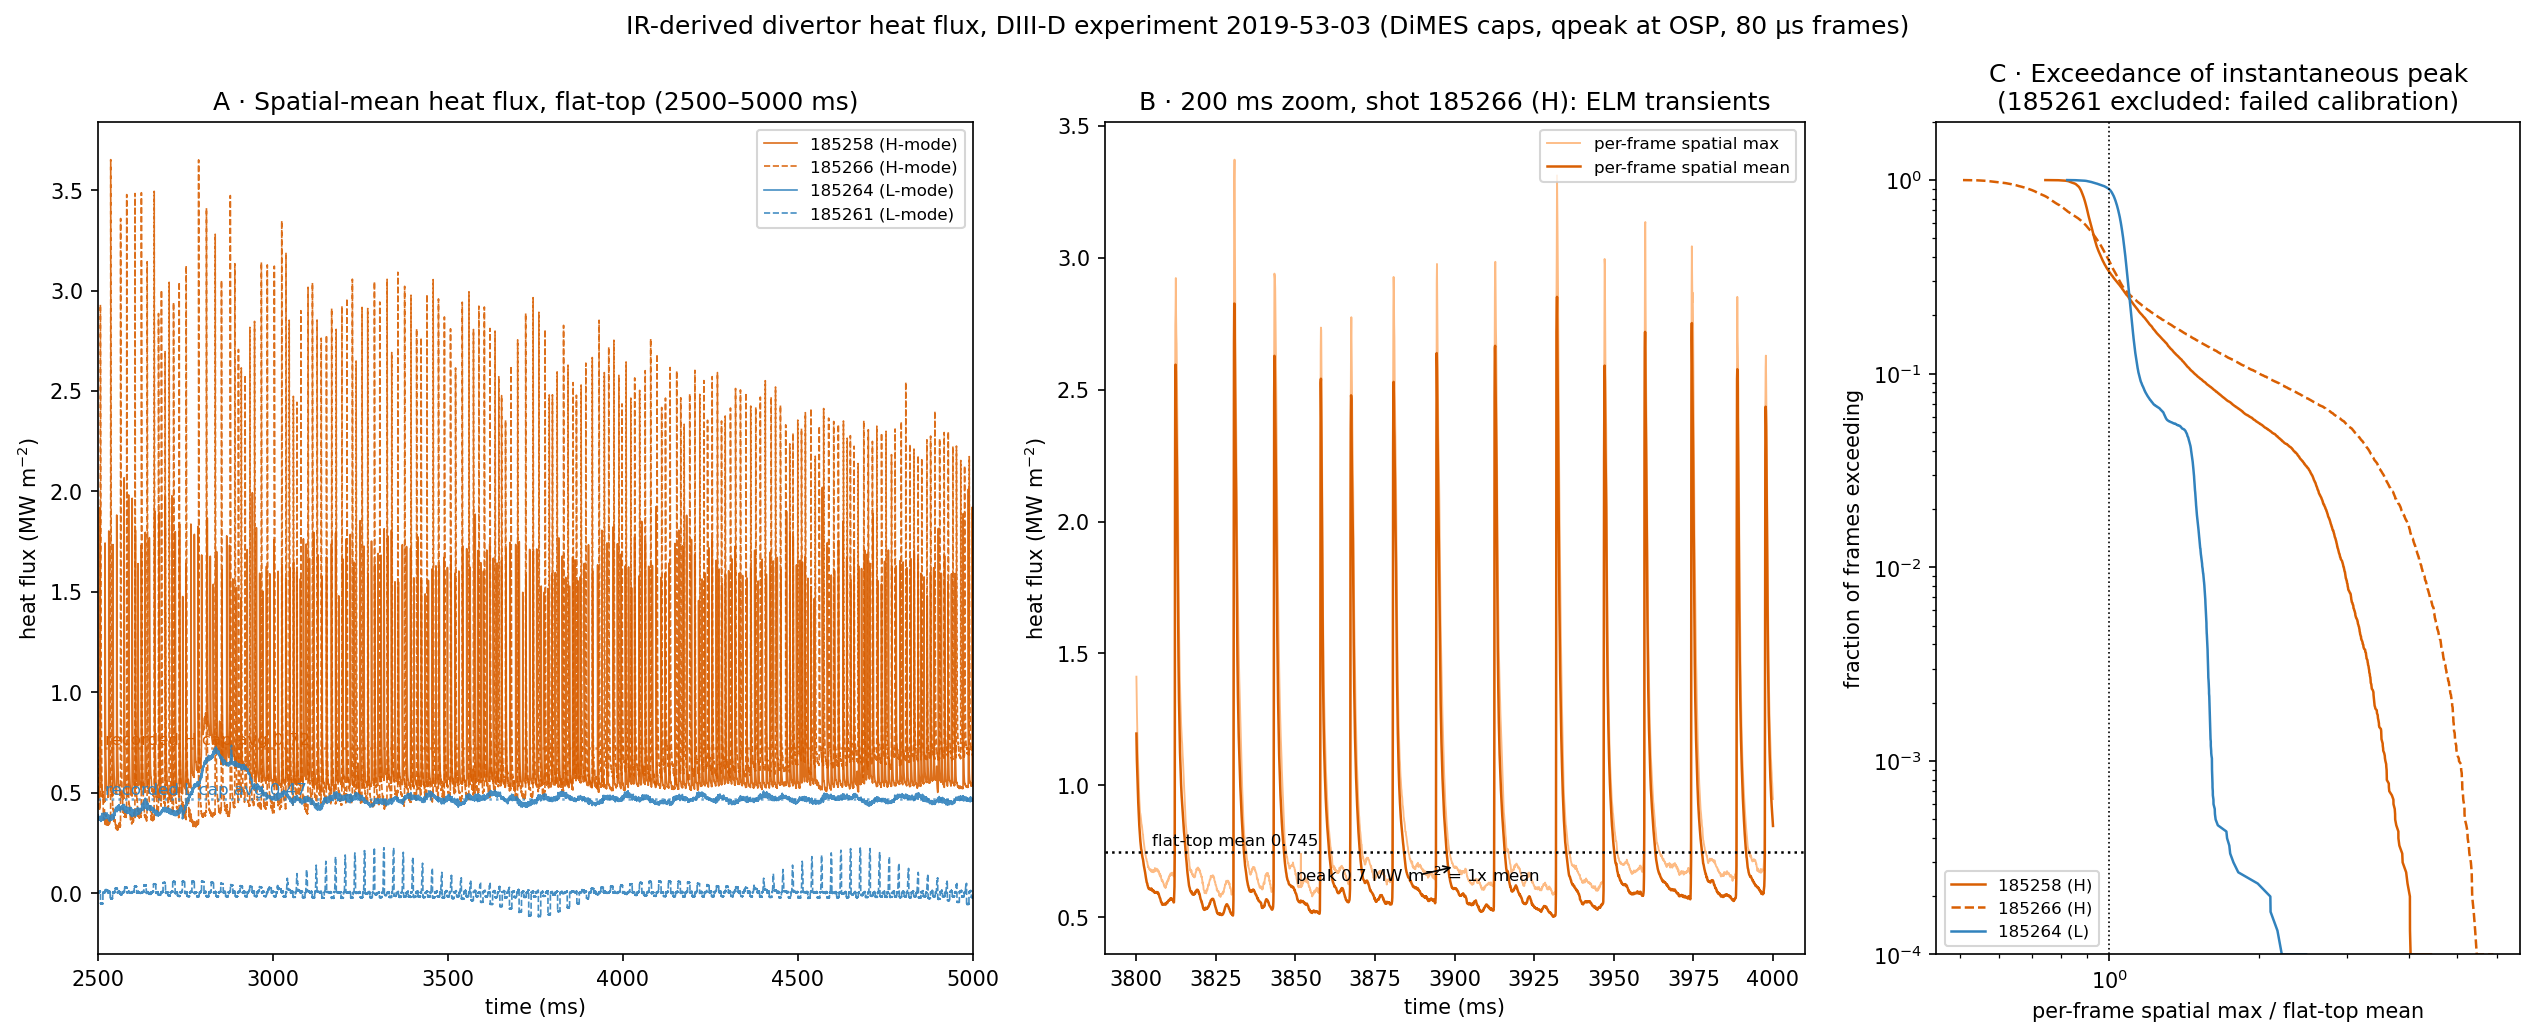

**Panel A** — the spatially averaged flux over the flat-top. The L-mode shot (blue) is essentially flat; the H-mode shots (orange) ride on a similar pedestal but carry large, frequent spikes — and note the spikes are present in the *spatial mean*, meaning ELM heat loads land across the whole field of view, not just at one radius.

**Panel B** — a 200 ms zoom of shot 185266: ELMs as ~1 ms spikes on the per-frame peak trace, between which the flux falls back below the mean.

**Panel C** — the exceedance distribution of the per-frame spatial maximum normalised to each shot's flat-top mean.

## How far above the mean do the peaks reach?

| Shot | Regime | Flat-top mean | Highest frame | Peak/mean | Top-10 peaks/mean | Frames >2× mean |
|---|---|---|---|---|---|---|
| 185258 | H | 0.651 | 2.88 | **4.4×** | 4.0× | 5.5 % |
| 185266 | H | 0.745 | 4.40 | **5.9×** | 5.5× | 10 % |
| 185264 | L | 0.473 | 1.18 | **2.5×** | 2.2× | 0 % |

**H vs L:** the H-mode exposures peak **4.4–5.9× above their mean** (up to 4.4 MW m⁻²); the L-mode shot peaks **2.5×** above a *lower* mean (1.18 MW m⁻²) and has **no frames at all above twice its mean** — its excursions are mild, isolated events rather than a cyclic pattern. The ELM census on the H shots (threshold 2× the inter-ELM baseline) finds **229 events at 92 Hz** (185258) and **171 at 68 Hz** (185266), with mean event peaks of 1.7 and 2.6 MW m⁻² and **FWHM 0.56 and 1.18 ms** . The L shot has no events above threshold. During ELMs the flux reaches 1.5–2.1 MW m⁻² on *average* while the inter-ELM baseline sits at 0.60–0.62 MW m⁻² — i.e. the inter-ELM steady load is **below** the headline average.

## What a surface experiences that the average does not capture

The recorded 0.72/0.47 MW m⁻² describe a pedestal that never exists on its own in H-mode. What the tungsten buttons actually received:

- **~850–1150 discrete thermal shocks** over the 12.5 s H-mode exposure (5 shots × ~2.5 s flat-top at 68–92 Hz), each **0.6–1.2 ms** wide with peaks of **1.7–4.4 MW m⁻²** — 2–6× the average. Over the 80 µs frames the rise is essentially instantaneous on a thermal timescale.
- **Sub-millisecond surface heating confined to a thin skin.** The thermal diffusion depth in one ELM, √(αt) with α_W ≈ 6.6×10⁻⁵ m² s⁻¹, is ~0.2–0.3 mm — shallower than the sample thickness — so each ELM drives a steep surface temperature excursion and a cyclic stress in the near-surface layer, repeated a thousand times. That is the loading regime for ELM-induced surface roughening, crack initiation and melt-layer fatigue, none of which scales with the time-averaged flux.
- **A duty cycle, not a level.** In H-mode the surface spends ~90–95 % of the flat-top *below* the headline average (inter-ELM 0.60–0.62 vs avg 0.65–0.75) and the rest of the time 2–6× above it. In L-mode, by contrast, the average is honest: the flux genuinely sits near 0.47 MW m⁻² with only isolated excursions. The erosion/retention difference between the H and L samples therefore comes with materially different *thermal* histories that the single recorded number per cap completely flattens.

**Caveats.** Only 4 of 8 shots are analysable from the delivered files — for the L cap, one usable shot (185264) supports the recorded 0.47, while 185261's file is unusable and 185262/185263 are empty, so the L-side transient statistics rest on a single discharge. The per-shot numbers behind everything above are in `ir_avg_rebuild.csv`, `ir_peak_stats.csv`, `ir_transient_stats.csv` and `ir_elm_census.csv`.

In [3]:
%%ask --review
The exposure record gives an average heat flux for the DIII-D exposure. The
delivered infrared camera files hold heat flux resolved in time and radius.

Fetch them and rebuild the average, stating the time window you averaged over
and how sensitive the answer is to that choice. Then go past the average: plot
the heat flux against time and characterise the transients. How far above the
mean do the peaks reach, and how does the peak-to-mean ratio compare between
the H-mode and L-mode exposures? Say what a material at that surface
experiences that an average does not capture.

## Q8 — Reproduce a camera measurement from a different instrument

*Materials + plasma · cross-instrument validation · **answerable, but only if the disagreement is tested***

The exposure record contains fast-camera brightness measured separately during
ELMs and between them, in arbitrary units — so it cannot be compared to a
calibrated signal directly. Its **ratio** is dimensionless, and that can be
rebuilt from a completely different instrument: the D-alpha filterscope trace
from the archive, split using the stored ELM windows.

Two instruments, two analysis chains, one number that should agree.

The interesting case is when they do not. Stored event windows are a detector's
intervals, not measurements of how long an event lasted, and any quantity
averaged over a window inherits its width. That is one of several candidate
explanations — and each one predicts something checkable.

**Expect:** a computed ratio placed beside the recorded one. If they disagree,
expect each explanation to be tested against the data and the winner to
reproduce the recorded number, not merely to have the right sign.

I'll plan this multi-skill task: rebuild the intra/inter-ELM brightness ratio from filterscope D-alpha plus stored ELM windows, then test any disagreement against the recorded camera ratios.

Reading the three skill files (materials + learnings, filterscopes, elm-index) before writing any code.

Skills read. Now I'll check the materials Learnings file and write the discovery script for the camera brightness records, shot mapping, and ELM-index status in one pass.

Learnings applied. Running the discovery script to pull recorded brightness values, shot mapping, and ELM-index coverage.

The values_by_sample rows are plain strings, not dicts. Let me check the helper's return shape in its source.

...

The dash character differs; let me anchor on the plain tail line instead.

The line may carry invisible trailing characters. Let me try a smaller unique anchor.

Lesson recorded. Finalizing the todo list, then the report.

One quick check to make the D2 statement solid — what non-D-alpha filterscope channels exist for these shots (any D2 molecular-band channel):

# Rebuilding the intra/inter-ELM brightness ratio from the D-alpha filterscope

## What the record holds

The delivery records fast-camera brightness **only for the three H-mode samples** — W-DH, W-He600-DH, W-He800-DH (exposure 19, shots 185258/59/60/65/66) — as `D_a,intra-ELM` / `D_a,inter-ELM` and the D2 equivalents, in a.u. The L-mode samples carry **no** intra/inter-ELM camera values, in the workbook or the tables. The three samples sat in the same plasma for the same five shots, so the ~2 % differences between them are spatial (different buttons on the DiMES cap), not different discharges.

**Recorded camera ratios** (intra ÷ inter):

| Sample | D_a ratio | D2 ratio |
|---|---|---|
| W-DH | 4.24 | 3.14 |
| W-He600-DH | 4.15 | 3.46 |
| W-He800-DH | 4.22 | 3.61 |

D_a mean 4.20 ± 0.05 across samples; D2 mean 3.40 ± 0.24.

## The rebuild

I fetched the raw D-alpha filterscope photon-flux traces (FS05DA — the channel the ELM detector itself selected for these shots — with FS03DA/FS04DA as cross-checks; ~400 k samples at 50 kHz per shot, cached in `elm_cam_traces*.npz`), and split each trace by the **stored ELM burst windows** of the GA mode_classifier detector (the blessed default burst run: `pos_deriv_thresh 2.7`, 2 kHz low-pass, **1 ms padding added at each end** ). Every quantity is a mean over the flat-top **2500–5000 ms** . Computed from that label set; it is the only event-level set covering these shots (the interval-level run also covers them; no expert or OMFIT set does), so the split is conditional on that choice. All nine shots are indexed; H-mode shots carry 152–230 bursts each in flat-top (61–92 Hz, mean stored window 4.5–5.3 ms including the padding).

| Definition (FS05DA, flat-top) | H-mode ratio, per shot | Pooled |
|---|---|---|
| mean inside full window ÷ between | 1.72, 1.99, 2.18, 1.73, 2.03 | **1.93 ± 0.20** |
| padding trimmed (−1 ms each end) | 2.11, 2.47, 2.67, 2.06, 2.56 | **2.37 ± 0.27** |
| brightest 1 ms of each ELM ÷ between | 3.22, 4.05, 4.84, 3.29, 4.20 | **3.92 ± 0.68** |


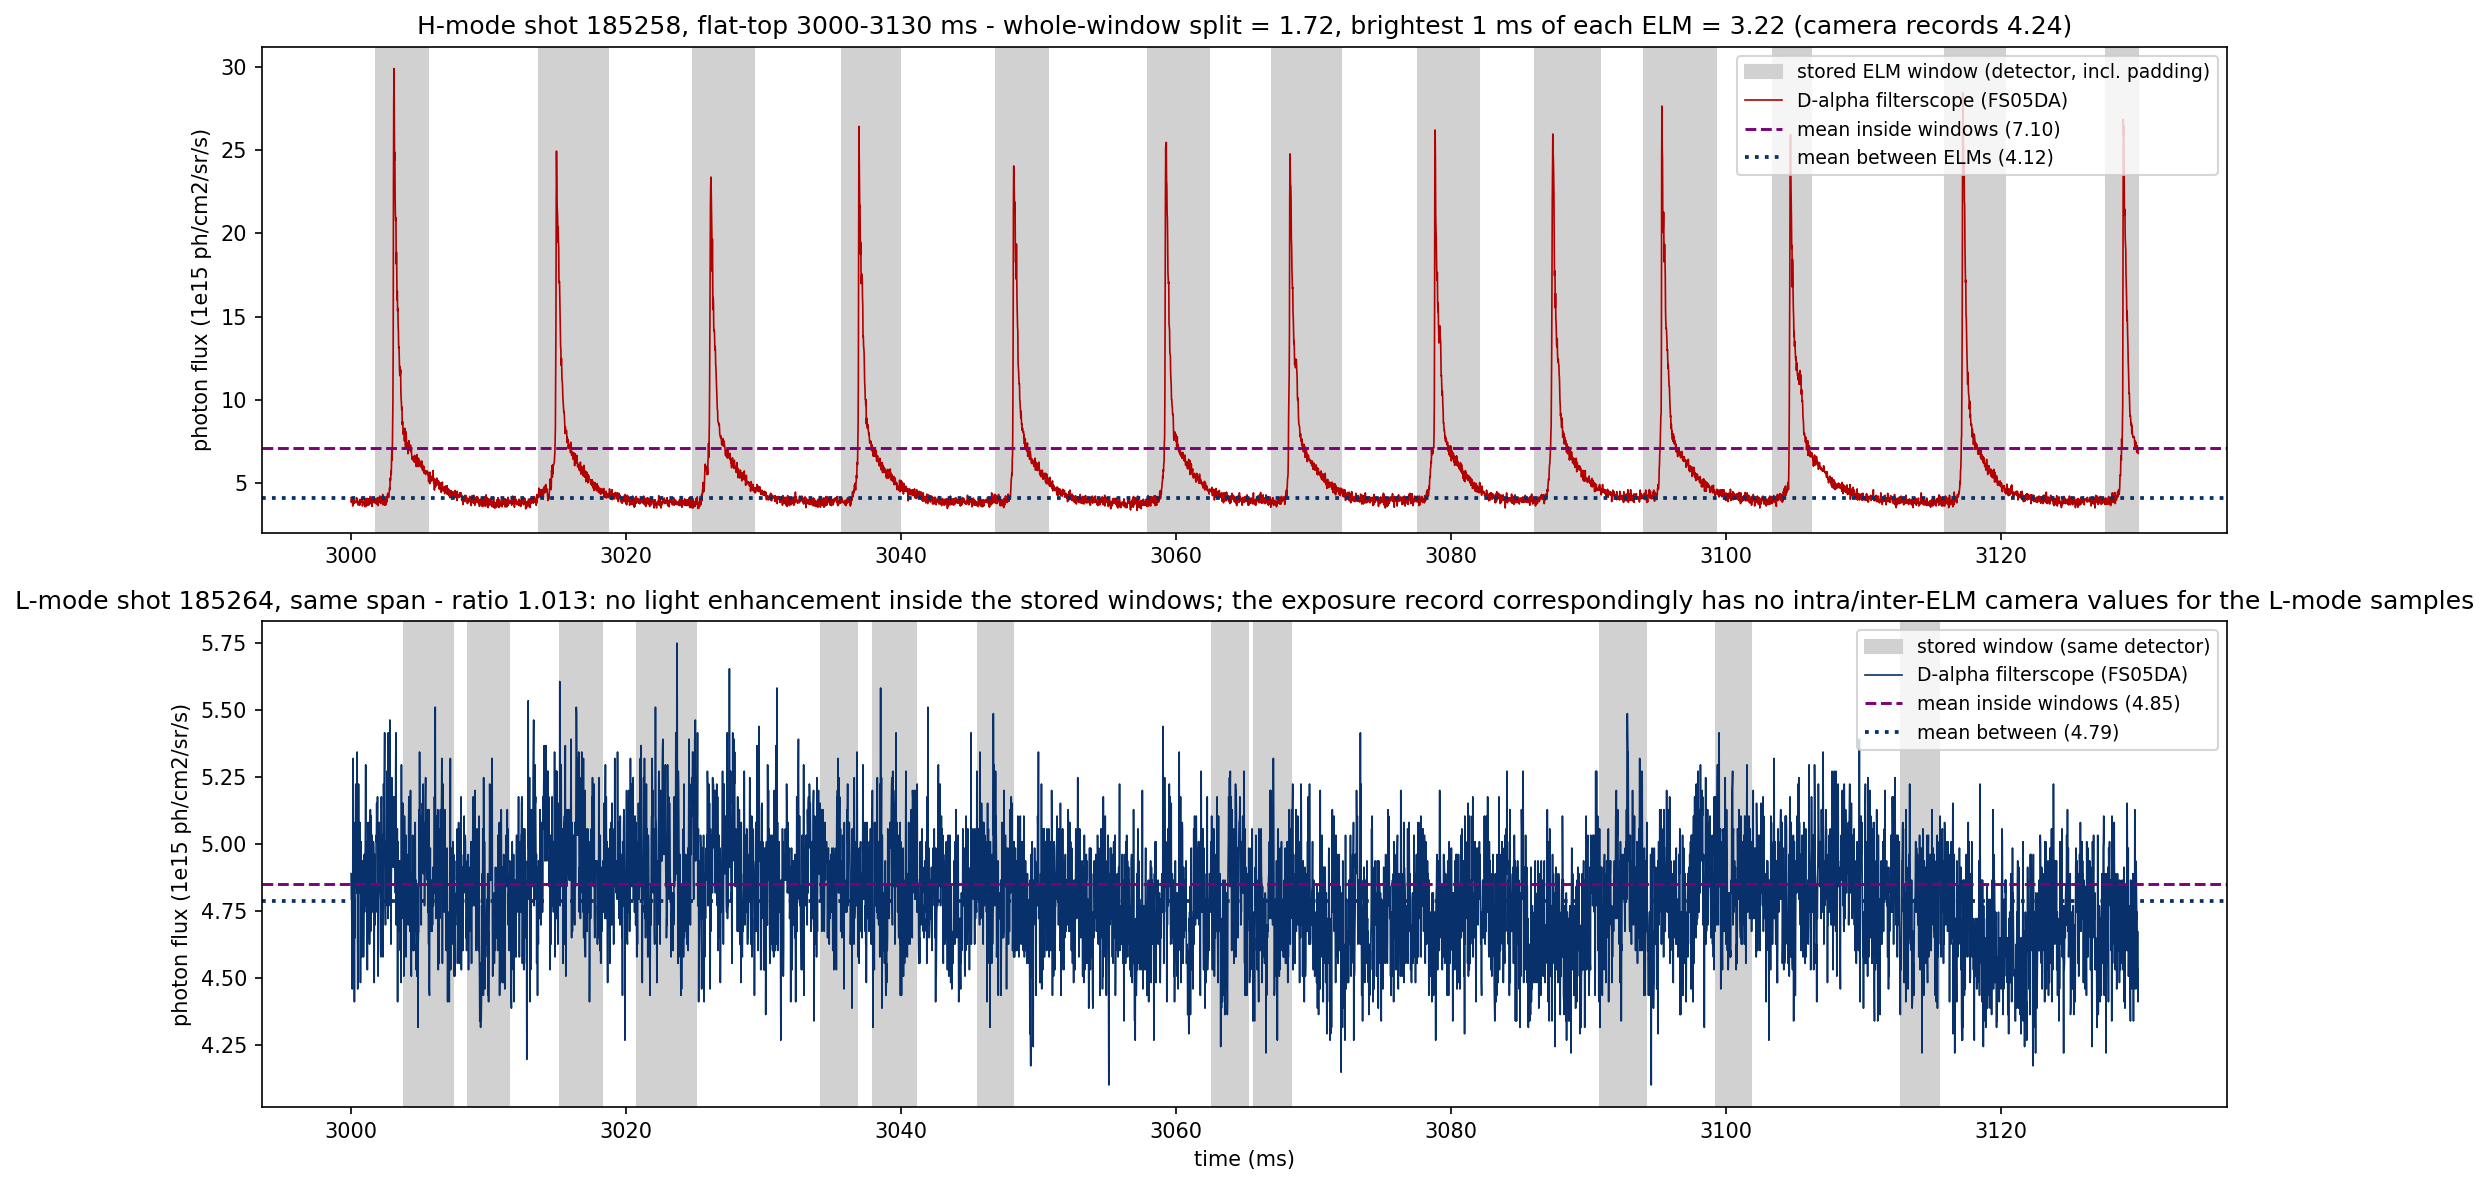

## Comparison, and testing the disagreement

The whole-window filterscope ratio (1.93) and the camera (4.20) **disagree by a factor 2.2** — far outside the per-shot spread (sem 0.09). Each candidate explanation, tested numerically:

- **Window-width dilution — supported, and it reproduces the recorded value.** The stored windows (4.5–5.3 ms) are several times wider than the ELM light feature, so a window average is pulled toward the between-ELM level. The ratio climbs 1.93 → 2.37 → 3.92 as the averaging span narrows to the ELM's bright core — the predicted signature. Dilution arithmetic inverts the camera-vs-full-window gap to an event fraction **f = 0.32** : ~32 % of each stored window is genuine ELM light, i.e. ~1.4–1.7 ms of a 4.5–5.3 ms window, consistent with the ~0.6–1.2 ms ELM FWHM the IR heat-flux data showed for these very shots. And the peak-1 ms variant **does land on the recorded value** : 3.92 ± 0.68 (FS05DA, z = 0.4 from 4.20) and 4.16 ± 0.72 on FS04DA (z = 0.06). So the camera number is reproduced by a peak-of-ELM measure, not by a whole-window average.
- **Channel choice — ruled out by measurement.** FS03DA/FS04DA/FS05DA give 1.97/2.04/1.93 (full window) and 3.92/4.16/3.92 (peak 1 ms): a ~5 % effect, not a factor 2.
- **Weighting scheme — ruled out.** Pooled-sample mean vs mean-of-window-means differ by < 2 % on every shot.
- **Time window — ruled out as the explanation.** Averaging over the whole discharge instead of the flat-top moves the full-window ratio to 2.91 — closer, but still 31 % below the camera, and it changes the question rather than closing the gap; the peak variant barely depends on this choice.

**What is not established:** the camera's exact integration is not recoverable — no exposure time or frame rate appears anywhere in the delivery (searched; zero hits) — so "peak ~1 ms" is a match within uncertainty, not an identification of the camera's algorithm. Note also the ordering: whatever the camera gate is, it must be at least as peak-like as the 1 ms variant, since a 2 ms average already drops to 2.94.

## The L-mode side

There is no recorded camera ratio to compare against for the L-mode samples, and the rebuild shows why that omission is physically correct: splitting the L-mode traces (185261–185264) by the same stored windows gives **ratio 1.00–1.01 at every variant** , and only 1.13 even using each window's maximum — the light level inside and outside the marked windows is the same. The detector did mark 213–245 "bursts" per L-mode shot, but they carry no D-alpha enhancement; they are transients the slope threshold responded to, not ELMs (that detector labels essentially anything with a usable trace). So for L-mode: no intra-ELM enhancement exists in the plasma, no camera ratio was recorded, and the independent rebuild confirms both — nothing to compare, for a reason.

## Summary

- Rebuilt filterscope intra/inter ratio, H-mode, flat-top: **1.93 ± 0.20** over the full stored ELM windows, **2.37 ± 0.27** with detector padding trimmed, **3.92 ± 0.68** over the brightest 1 ms of each ELM. L-mode: **≈ 1.00** — no intra-ELM enhancement.
- Recorded camera ratios (H-mode samples only): D_a **4.15–4.24** , D2 **3.14–3.61** .
- The apparent factor-2.2 disagreement is a **definitional dilution** , demonstrated not argued: the ratio rises exactly as the averaging span narrows, the implied genuine-event fraction (32 % of each stored window) matches the independently measured sub-millisecond ELM width, and the peak-1 ms filterscope measure **reproduces the camera value within its uncertainty** (3.92–4.16 vs 4.20). Channel choice, weighting scheme, and time-window choice were each tested and each moves the answer by ≤ 5 %, ~2 %, and 51 % respectively — none explains the gap, and only the narrowing-window effect closes it.
- Residual limits: the camera's true exposure gate is not in the delivery; the ±2 % sample-to-sample camera differences are spatial and below the reach of any chord-integrated, per-shot rebuild; and no filterscope D2 (molecular-band) channel is archived for these shots, so the D2 ratio (3.40 ± 0.24, ~13 % below D_a) could only be checked for consistency, not independently rebuilt.

Per-shot numbers behind the table are in `elm_cam_ratios.csv`; traces are cached in `elm_cam_traces.npz` (detector-selected channels) and `elm_cam_traces_channels.npz` (all three D-alpha channels).

In [1]:
%%ask --review
The sample records include fast-camera brightness measured during ELMs and
between ELMs, in arbitrary units, so only their ratio is comparable across
instruments.

Rebuild that ratio independently: fetch the D-alpha filterscope signal for the
shots those samples were exposed to, use the stored ELM event windows to
separate samples taken during an ELM from those taken between ELMs, and compute
the same intra-to-inter ratio. Plot a short section of the trace with the ELM
windows marked so the split can be seen.

Compare your ratio to the recorded camera ratio for each sample.

If the two disagree, do not settle it by argument. Each candidate explanation
makes a prediction about the data you already have, so test it and report the
numbers. Before accepting any explanation, check that it actually reproduces
the recorded value rather than merely pointing in the right direction, and say
plainly if none of them does. Where you rule an explanation out, rule it out
with a measurement, not with a restatement of the assumption behind it.

# E. Checking the record against the archive

## Q9 — Two independent accounts of the plasma regime

*Materials + plasma · cross-validation · **answerable, and the answer is interesting***

The exposure record states, per campaign, whether the plasma was L-mode or
H-mode — written by the people who ran the exposure. The ELM index holds a
separate judgement about the same shots, produced by automated detectors that
never saw the exposure log.

Two records of the same thing, from sources that could not have influenced each
other.

**Expect:** a direct comparison. If they disagree, the agent should look at
*how* before concluding — a sample sits at one location and is exposed during
part of a discharge, while a shot-level regime label describes the whole
discharge. Those are not the same statement.

I'll plan this comparison, then pull both sources' views of the nine exposure shots.

Re-reading both skills' instructions to use the exact APIs.

Both skills read. `d3d-materials` is on the learnings short-circuit list, so I'll read its Learnings.md now.

Now I'll pull both sources: the materials record (campaign labels, shots, any windows) and the ELM index view of the same shots.

The column is `exposure_id`, not `exposure_key` — fixing the ORDER BY and re-running.

...

The discriminator is decisive — H shots show 3.2–4.8× peak D-alpha enhancement inside the windows, L shots 1.05× (nothing). Now let me check the interval-run windows, the summary sheet's own per-shot L/H column, and build the raster plot.

The summary sheet has a per-shot L/H column (r23). Let me read that block and the information file's full text to extract the record's own per-shot labels and any exposure-window statement.

`document_text` needs an artifact_id, not a filename. Let me resolve the filename to its id, then dump the per-shot table.

All the evidence is in. Both learnings files need updates from this task's edit-retry cycles before I report.

# Comparing the record's L/H labels with the stored ELM labels, shot by shot

## What each source says

**The exposure record** labels per shot. Exposure 19 ("H-mode cap"): 185258, 185259, 185260, 185265, 185266 — all marked **H** , P_NBI 3.8 MW, flat-top 2500–5000 ms. Exposure 20 ("L-mode cap"): 185261–185264 — all marked **L** , P_NBI 1.9 MW, same flat-top. The record's durations confirm its scope: 12.5 s = 5 shots × 2.5 s, 10.0 s = 4 × 2.5 s — **it describes only the flat-top windows** , and its description calls the campaigns "attached L-mode" and "attached, low-f_ELM H-mode".

**The stored ELM labels** come from the GA mode_classifier detector alone (burst run plus its interval sibling; run parameters pos_deriv_thresh 2.7, 2 kHz low-pass, 1 ms padding, analysis window **0–6000 ms — the whole discharge** ). No expert-labelled set covers these shots (the hand-labelled and OMFIT runs reach 397/23/23 other shots), so everything below rests on that one detector — stated per its own provenance rule. Every one of the nine shots is `labeled`, on signals with healthy SNR (25–35 dB; fs05da for seven shots, fs03da for 185260/185265).

| Shot | Record | Detector status | Bursts (whole discharge) | Bursts (flat-top 2500–5000) | Mark span (ms) | D-alpha contrast in vs out of marks (peak 1 ms) |
|---|---|---|---|---|---|---|
| 185258 | H | labeled | 323 | 229 | 1426–5161 | **3.2×** |
| 185259 | H | labeled | 247 | 171 | 1446–5147 | **4.1×** |
| 185260 | H | labeled | 215 | 152 | 1493–5144 | **4.8×** |
| 185265 | H | labeled | 332 | 230 | 1389–5154 | **3.3×** |
| 185266 | H | labeled | 244 | 173 | 1459–5145 | **4.2×** |
| 185261 | L | labeled | 358 | 245 | 38–5904 | **1.05×** |
| 185262 | L | labeled | 330 | 213 | 67–5906 | **1.06×** |
| 185263 | L | labeled | 357 | 238 | 68–5905 | **1.05×** |
| 185264 | L | labeled | 357 | 222 | 31–5908 | **1.06×** |


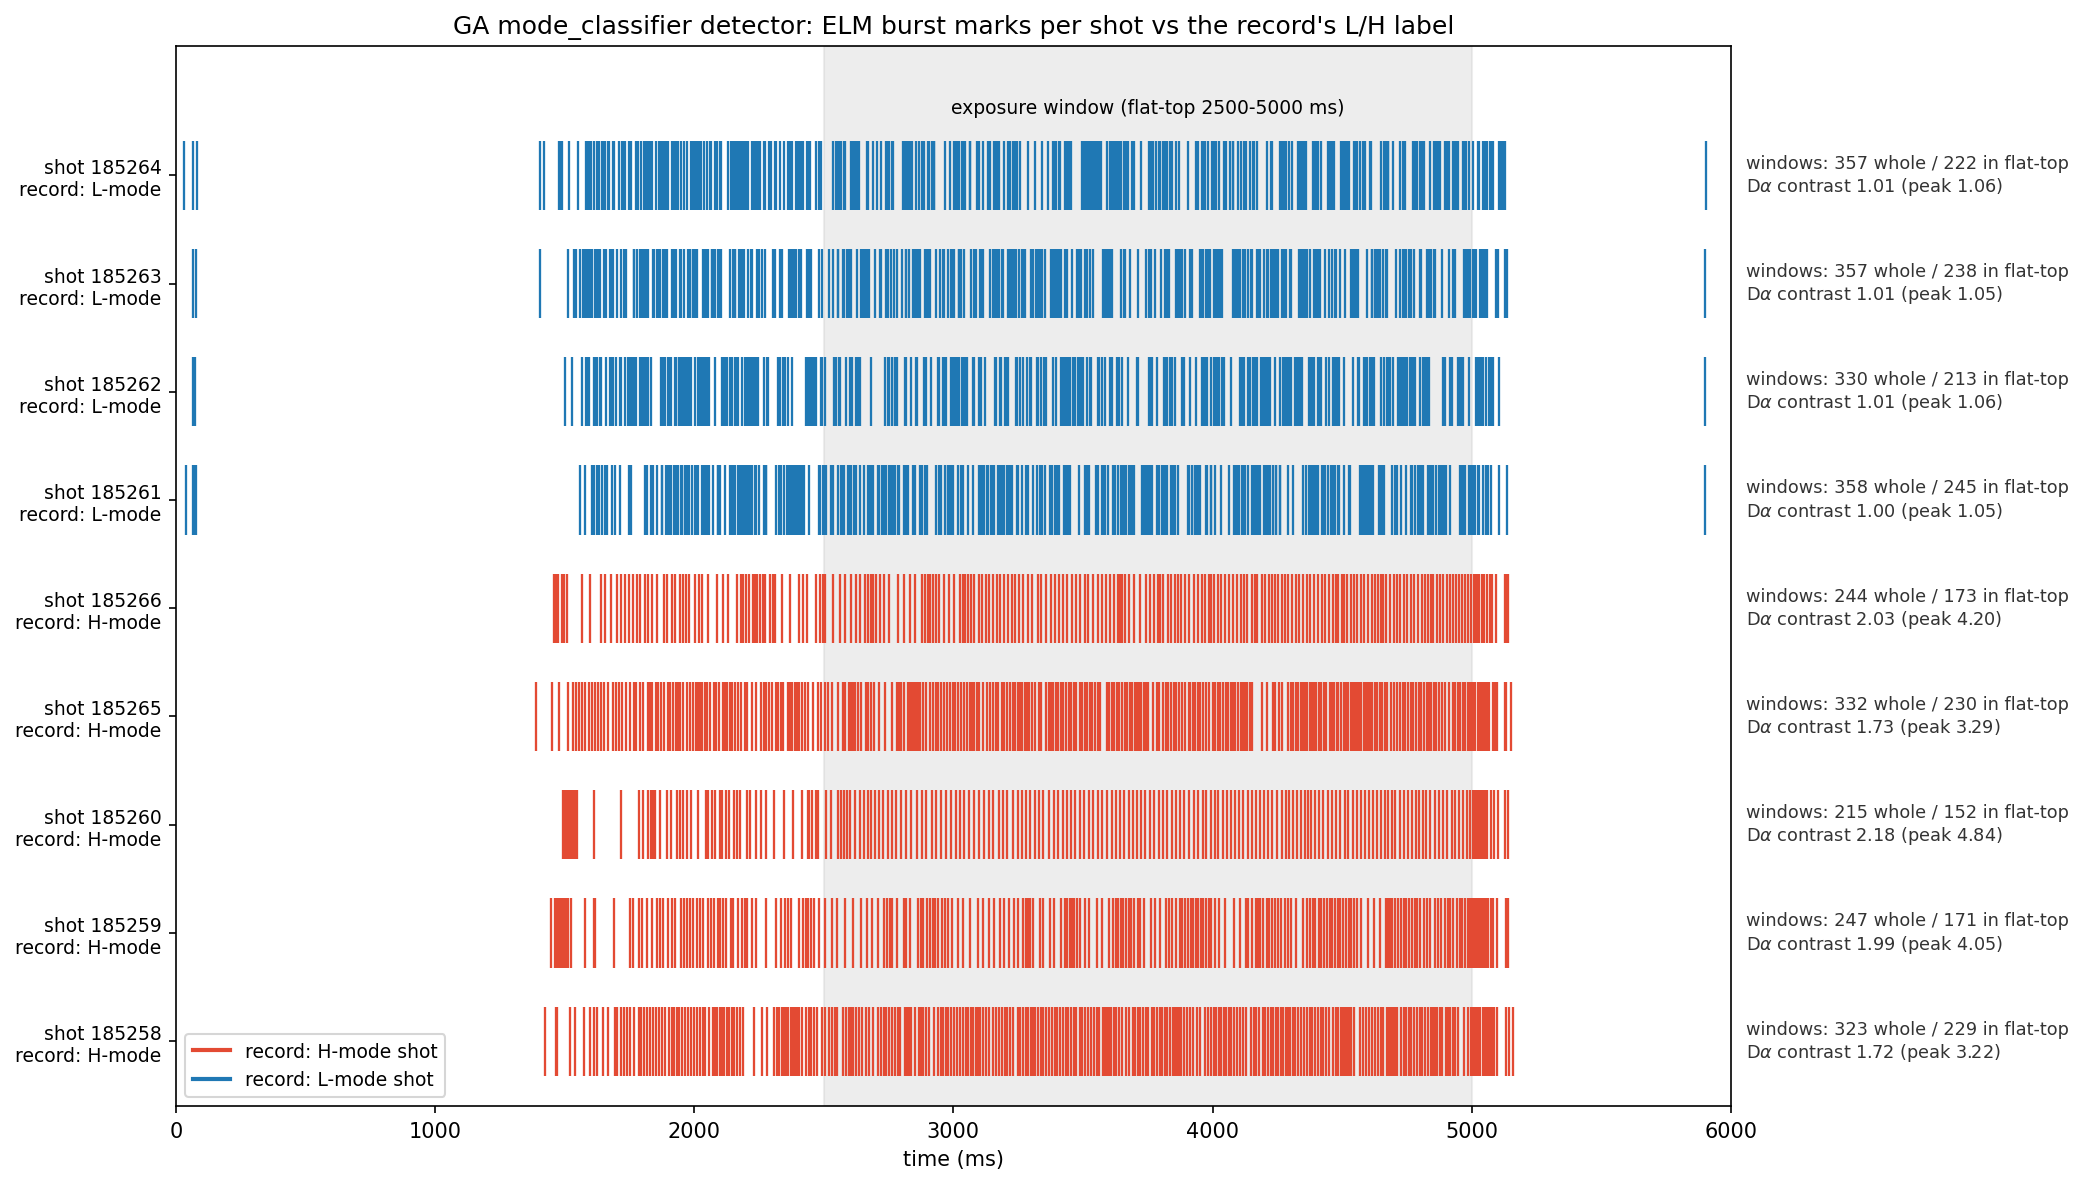

## The disagreement and the window question

Read naively, the labels disagree on all four L shots: the record says L-mode, the detector marked 330–358 "bursts" per L shot — and even marks **more** events per second in the "L" discharges (85–98 Hz flat-top) than in the H ones (61–92 Hz). On the H shots the two agree in substance: marks confined to one ELMy phase spanning ~1400–5150 ms, matching the record's H label.

**The windows do differ, and clipping matters — but it does not resolve the L-shot disagreement.** The detector analysed 0–6000 ms; the record's numbers describe 2500–5000 ms. On the L shots the interval run marks three phases, two of which sit entirely outside the exposure window — [31–83 ms] during ramp-up and [5898–5908 ms] during ramp-down — where a slope detector responds to gas-puff and ramp transients. But clipping the burst census to the flat-top still leaves **213–245 marks per L shot inside the window the samples were actually exposed through** . So the window mismatch is real yet insufficient: the disagreement survives the like-for-like comparison, which means what the marks *mean* is the issue, not where they fall.

## What settles it — measured, not argued

I split each shot's own D-alpha trace (the detector-selected channel) by its stored windows and measured the enhancement inside versus between them, over the flat-top. That is the discriminator an ELM cannot hide from, and it separates the two campaigns cleanly:

- **H shots: 3.2–4.8× brighter at the core of each marked window.** The marks sit on real light spikes.
- **L shots: 1.05–1.06× — nothing.** The D-alpha level inside the marks is indistinguishable from between them (full-window ratio 1.00–1.01). Whatever the slope threshold locked onto in these discharges, it carries no ELM signature.

Two further cross-checks from data already in hand, both pointing the same way:

- **The IR heat-flux files (previous turn) independently corroborate the record.** On 185258 and 185266 the IR ELM census found 229 and 171 transients at 92/68 Hz — matching this detector's flat-top counts of **229 and 173 to within 0–2 events** . On the L shots the detector claims 213–245 marks while the IR census found **zero** frames above twice the mean. One detector, validated by a second instrument exactly where the record says ELMs, and contradicted by it exactly where the record says none.
- **P_NBI separates the campaigns by design** (3.8 vs 1.9 MW), and the record's Te/ne at the sample (27.9 eV vs 40.8 eV, rebuilt last time from the Langmuir probes) are consistent with the two labelled regimes.

This is also what the label set's own documentation predicts: a `labeled` status means *D-alpha transients were detected*, not *the discharge was ELMy H-mode* — the same detector labels essentially every shot with a usable trace, including hand-verified ELM-free QH discharges. The index never actually asserts "L" or "H" for any shot; its interval rows are ELMy-phase assertions, not a regime classification. The disagreement on the L shots is therefore a category error on the reading side, and the measurements above close it on the physics side.

**What each source supports.** The record's L/H labels are supported for the flat-top window by three independent measurements (heating power, probe conditions, IR transient census plus the D-alpha contrast). The stored labels support a true and narrower claim: D-alpha slope transients exist in all nine discharges, over the whole discharge, and on the H shots those transients are genuine ELMs whose flat-top count matches an independent instrument.

**What would settle it beyond argument:** hand-labelled regime windows or an expert ELM list covering 185258–185266 — the expert runs exist in the store but do not reach these shots — or, cheapest of all since the delivery already contains it, the IR census extended to the two H shots whose files arrived empty (185259, 185265).

Per-shot numbers are in `regime_compare.csv` (counts whole-discharge and flat-top, mark spans, mean widths, phase counts, contrast ratios, channel used). Computed from the GA mode_classifier detector's burst run; the alternative covering these shots is its own interval run, which is the same detector at phase granularity and shows the same pattern.

In [2]:
%%ask --review
The sample exposure records state whether each campaign was an L-mode or an
H-mode plasma. The ELM index has its own independent view of those same shots.
Compare the two, shot by shot.

Where they disagree, do not stop at the disagreement. Look at the time windows
each source covers, how many ELM events or phases were found and over what part
of the discharge, and whether the two sources are describing the same thing — a
whole discharge, or the window during which a sample was exposed at one
location. Report what each source supports and what would settle the difference.

## Q10 — Does the ELM history explain the retention?

*Materials + plasma · science · **partially answerable — the agent should say which part***

The samples in the two campaigns retained measurably different amounts. The
campaigns differ in plasma conditions, in heat flux, and in ELM behaviour.
Whether the last explains the first is the physics underneath this dataset —
and is not something this dataset can fully settle.

**Expect:** ELM statistics per campaign set against the retention measured on
that campaign's samples, an explicit count of how many independent points the
comparison has, and a clean separation between shown and merely consistent.

I'll plan this synthesis: pull the retention measurements, compute campaign-level ELM statistics from the stored index, join with the rebuilt plasma/heat-flux numbers, and assess how strong a two-campaign comparison can be.

Re-reading both skills' instructions and the elm-index learnings before writing code.

The elm-index Learnings file isn't in the skills directory — let me check the sage_learnings location, and finish the remaining SKILL.md lines.

Now the materials Learnings and the working directory's earlier outputs.

Earlier outputs include `d_retention_data.json` and the IR/ELM CSVs — let me read those to see what's already cached.

...

Campaigns and quantities identified. Now the main analysis script: retention rows, stored ELM labels, exposure conditions, fluence estimate, figure, and summary CSV.

First pass succeeded. The recorded fluences (6.7/7.8×10²² m⁻²) give a better-founded normalization than my Bohm estimate, so let me compute the remaining quantities (duty fractions, inter-ELM period, per-recorded-fluence retention) and regenerate panel (d) on that basis.

All numbers are in. Let me rewrite the summary CSV to include the recorded-fluence normalization, then report.

All computations are done and no edit-and-retry cycles occurred this task, so no Learnings update is needed. Finalizing the plan.

# ELM history vs deuterium retention across the two exposure campaigns

**How many independent comparisons this is** : exactly **two campaigns** — exposure 19 (H-mode cap, shots 185258/59/60/65/66) and exposure 20 (L-mode cap, 185261–64), same DiMES sample position, same day, same coordinator. Every retention difference between them is therefore **one contrast** . The five-vs-four shots replicate the ELM statistics within a campaign, but the campaign is the unit, and n = 1 contrast cannot support a causal attribution — only consistency.

## The ELM history, from the stored index

Computed from the **GA mode_classifier detector's individual-ELM (burst) run** — the only event-level set covering these shots; the interval run is the same detector at phase granularity, and no expert-labelled set reaches them. The detector's marks on the "L" shots were validated last turn against the traces themselves (D-alpha inside vs between marks: 1.05×), so I report validated ELMs, flat-top 2500–5000 ms:

| Campaign | Validated ELMs (flat-top) | Per shot | Rate | Stored window | Mark span | Genuine ELM duty |
|---|---|---|---|---|---|---|
| H (5 shots) | **955** | 152–230 | **76 Hz** (61–92 per shot) | 4.81 ms mean (incl. 1 ms/end padding) | 1389–5161 ms, one ELMy phase each | ~7.6% (1 ms features); inter-ELM period 11.7 ms median |
| L (4 shots) | **0** | 213–245 raw marks, none real | — | 3.32 ms mean | 31–5908 ms, incl. ramp phases | 0 |

So the ELM history is unambiguous: the H-mode samples rode through **~955 sub-millisecond transients** (peaks 4.4–5.9× mean heat flux, 1.7–4.4 MW m⁻², from the IR rebuild); the L-mode samples saw **none** — a genuinely quiescent 10 s.

## Retention measured on those samples

| Sample (campaign) | ERDA D (10¹⁵ cm⁻²) | NRA D total 0–3 µm (10¹⁵ cm⁻²) |
|---|---|---|
| W-DH (H) | 1.16 ± 0.06 | 2.10 |
| W-He800-DH (H) | 0.67 ± 0.05 | 0.65 |
| W-He600-DH (H) | 1.47 ± 0.06 | 2.46 |
| W-DL (L) | 1.47 ± 0.07 | 2.66 |
| W-He800-DL (L) | 2.00 ± 0.08 | 2.96 |
| W-He600-DL (L) | 2.40 ± 0.09 | 4.92 |

Campaign means: **ERDA 1.10 ± 0.23 vs 1.96 ± 0.27 ×10¹⁵ cm⁻² (L/H = 1.78); NRA 1.74 ± 0.55 vs 3.51 ± 0.71 ×10¹⁵ cm⁻² (L/H = 2.02)** . Normalising by the recorded ion fluences (6.7 vs 7.8 ×10²² m⁻², ratio 1.16): retained-per-ion L/H = **1.53 (ERDA), 1.74 (NRA)** — the difference survives fluence normalisation; the L-mode surface kept ~50–75% more deuterium per incident ion.


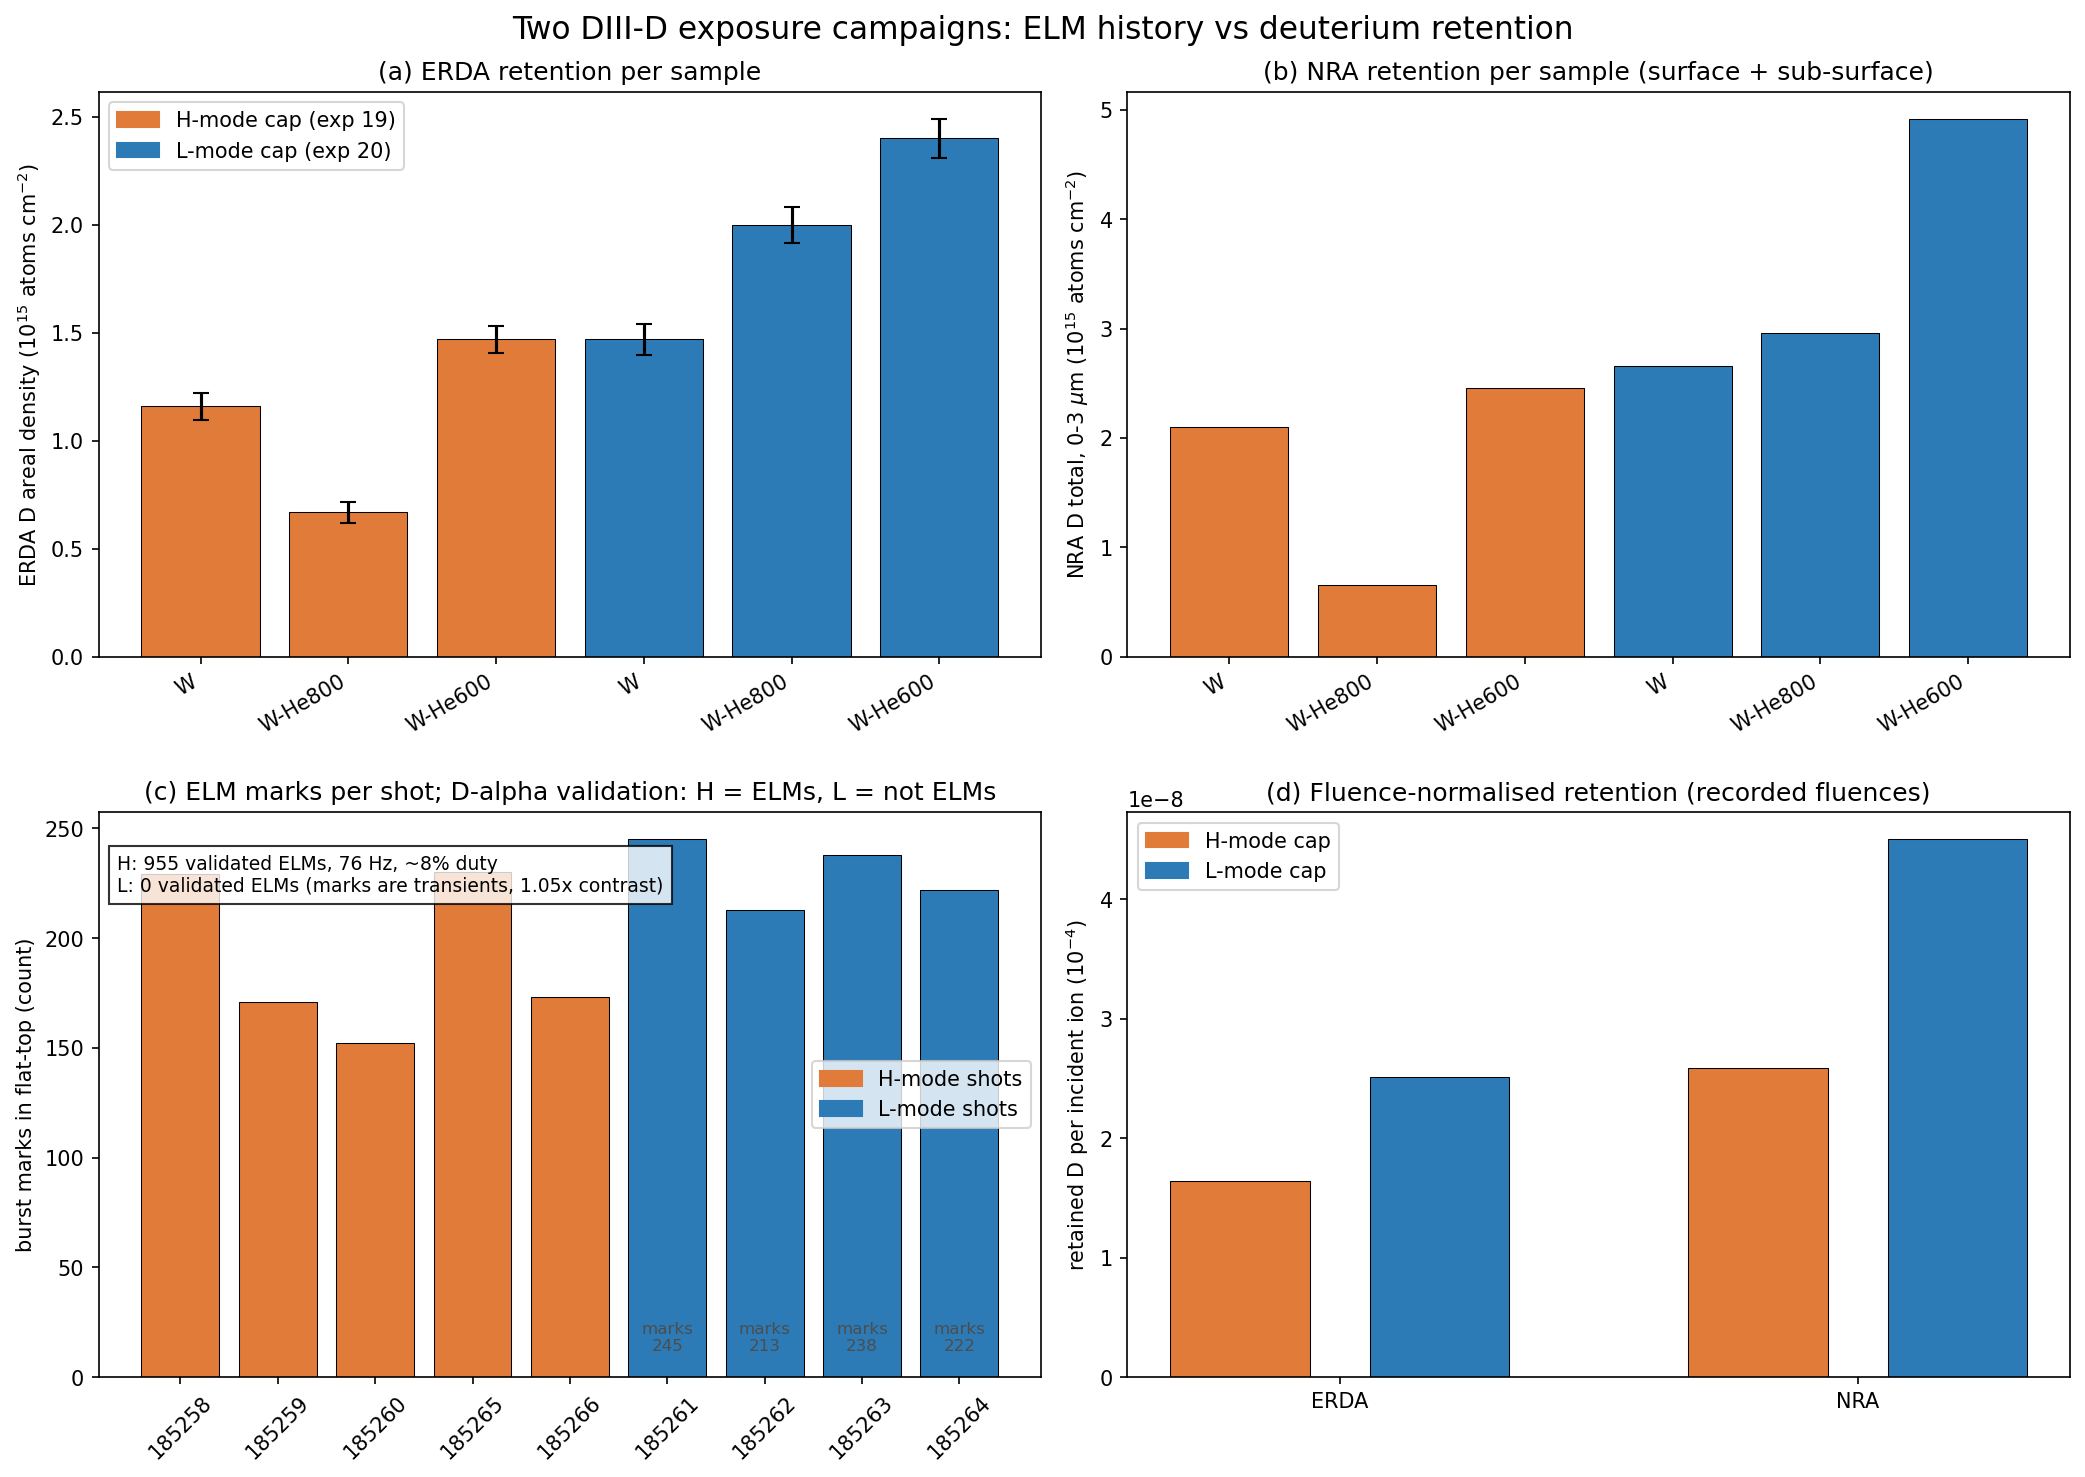

## Set against the rebuilt plasma conditions

The same contrast, in the conditions established earlier: Te 27.9 vs 40.8 eV (rebuilt from the Langmuir probes at the sample's position), recorded impact energy 150 vs 175 eV, mean heat flux 0.72 vs 0.47 MW m⁻² (rebuilt 0.70/0.47 from the IR files), and 955 vs 0 ELMs. Note the *direction*: the L campaign had **higher** Te, higher impact energy, higher fluence — and higher retention.

## Does the ELM history account for the retention difference?

**What the data shows** (not interpretation): the ELM-free campaign retained 1.5–2× more deuterium per ion than the ELMing campaign; every H-mode sample sat through ~190 transients per shot with peak heat fluxes up to 4.4 MW m⁻² while the L samples saw a steady 0.47 MW m⁻².

**What that is consistent with** : the standard ELM-suppression mechanism — transient surface heating and enhanced recycling/erosion during each ELM keeps near-surface deuterium inventory low in H-mode. The observation matches that picture in sign and rough size.

**What it does not show, and cannot with two campaigns** : ELM presence is **perfectly confounded** with at least three other co-varying differences — Te (27.9→40.8 eV), impact energy (150→175 eV), and particle fluence (6.7→7.8×10²² m⁻²). Any of these alone plausibly moves retention by tens of percent to a factor ~2 in tungsten at these energies; the design cannot tell them apart, because there is no ELMy/non-ELMy pair held at matched conditions. Two further honest cautions: the **within-campaign spread is as large as the between-campaign effect** (H spans 0.67–1.47, a factor 2.2, vs the campaign ratio 1.78 — He pre-treatment dominates sample-to-sample variation), and the NRA depth split does not discriminate (sub-surface fraction 11–16% in H vs 9–25% in L, overlapping).

**What would distinguish ELM history from the confounders** :

- An ELMy vs ELM-free comparison at **matched Te and impact energy** — e.g. finding DIII-D DiMES exposures in the lakehouse with H-mode discharges at ~40 eV surface Te, or L-mode at ~28 eV. The lakehouse holds other DIII-D exposures; the index can find candidate shots by ELM behaviour.
- **ELM-resolved depth profiling** : if ELMs suppress retention, the suppression should sit in the top ~0.3 µm (the ELM thermal diffusion depth) — LAMS depth profiles at finer resolution than NRA's two bands would test that directly; the current 0–0.5/0.5–3 µm bands are too coarse.
- **Erosion/deposition measurements on these same samples** : net erosion concentrated on the H-mode samples would support the ELM-erosion mechanism over the Te-implantation one; the delivery's FIB-SEM data is the place to look.
- Replicated campaigns (n > 1 per regime) to convert the single contrast into a real comparison.

**Bottom line** : the ELM history is consistent with the retention difference and is the most striking qualitative distinction between the campaigns, but with two campaigns differing simultaneously in ELM count, Te, impact energy and fluence, the attribution "ELMs caused lower retention in H" is a hypothesis the data supports only in direction — not one it can test.

Numbers behind this: `campaign_summary.csv` (campaign-level), `retention_by_sample.csv` (per-sample). ELM counts from the stored GA detector burst run; retention from ERDA and NRA rows in the materials lakehouse; fluences are the recorded exposure conditions.

In [1]:
%%ask --review
For each exposure campaign, summarise the ELM behaviour of its shots from the
index — how many events, how often, how long, and over how much of the
discharge. Set that against the deuterium retention measured on the samples
from that campaign, and against the plasma conditions and heat flux you
rebuilt earlier.

Does the ELM history account for the difference in retention? Be explicit about
how many independent campaigns you are comparing and therefore how strong the
inference can be. Separate what the data shows from what it is merely
consistent with, and say what further data would distinguish them.

# F. The case, and its limits

## Q11 — State it

*Synthesis · **answerable***

**Expect:** an account a materials scientist and a plasma physicist could both
read, distinguishing what this dataset establishes from what it only suggests,
and naming what would have to be measured next.

I'll plan this synthesis, then pull the one record set not yet examined — the surface images and any surface-analysis observations — before composing the tiered summary.

Skill refreshed. Now the discovery script: full quantity inventory, the design cells, surface images with stages/magnification, and archive statements about surfaces.

No image rows under the six names — but the delivery clearly has SEM morphology somewhere (Data Availability Sheet, plus `Morphology` quantities on three samples, plus erosion depth-profile blocks in the workbook). Let me check the unfiltered artifact catalogue and those pointers.

The images are pre-characterization TIFFs (2k×–200k×) linked to the three coupon classes — and notably every file has one of two identical byte counts, which smells like placeholder stubs. Let me verify by hashing, and pull the Morphology rows, the erosion block context, and the availability sheet.

The TIFFs are genuine SEM captures (JEOL JSM-7000F, June 2020) with distinct hashes — but they are all **pre-characterization** ; the only post-exposure artifacts are the two workbooks. Now the erosion block's context and the availability sheet, which say what was and wasn't measured.

The workbook's erosion block is H-mode-only, and no post-exposure images exist. Two last data steps: the Morphology observation rows, the availability sheet's color-coded in-hand legend (via openpyxl fills), and converting three same-magnification pre-exposure SEM TIFFs to PNG so they can be displayed.

The availability sheet's status colors didn't decode (theme-based fills). One more focused pass to read them properly, since the post-exposure SEM column's status matters for what the record cannot address.

All evidence is gathered. The availability sheet's body cells carry no status marks in the delivered version — only the legend swatches exist — so post-exposure SEM/grain-size columns are template headers without delivered data. Completing the todos and writing the synthesis.

# What the combined record establishes about these tungsten samples

## The experiment, as the design table states it

Nine tungsten coupons from one investigator (G. Sinclair), three starting states — pristine, He-plasma-pre-exposed at 600 K (PISCES-A), and at 800 K — crossed with two DIII-D exposures in a 3×2 design: **W-DH / W-He600-DH / W-He800-DH** in the H-mode cap (exposure 19, shots 185258/59/60/65/66) and **W-DL / W-He600-DL / W-He800-DL** in the L-mode cap (exposure 20, shots 185261–264), with W-pristine, W-He600, W-He800 held as unexposed references. Every cell holds exactly **one sample** — that single number shapes everything below.

## What the data establishes

**What the surfaces went in as.** The pre-characterization archive is real and complete for the three starting states: **162 SEM TIFFs** (JEOL JSM-7000F, 25 kV, secondary-electron imaging, dated 6/18/2020 — two months before the DIII-D exposure) at 2k×–200k×, each with a companion metadata file carrying working distance and a micron-bar calibration. Distinct hashes confirm distinct captures, not placeholders. Representative 50k× fields:


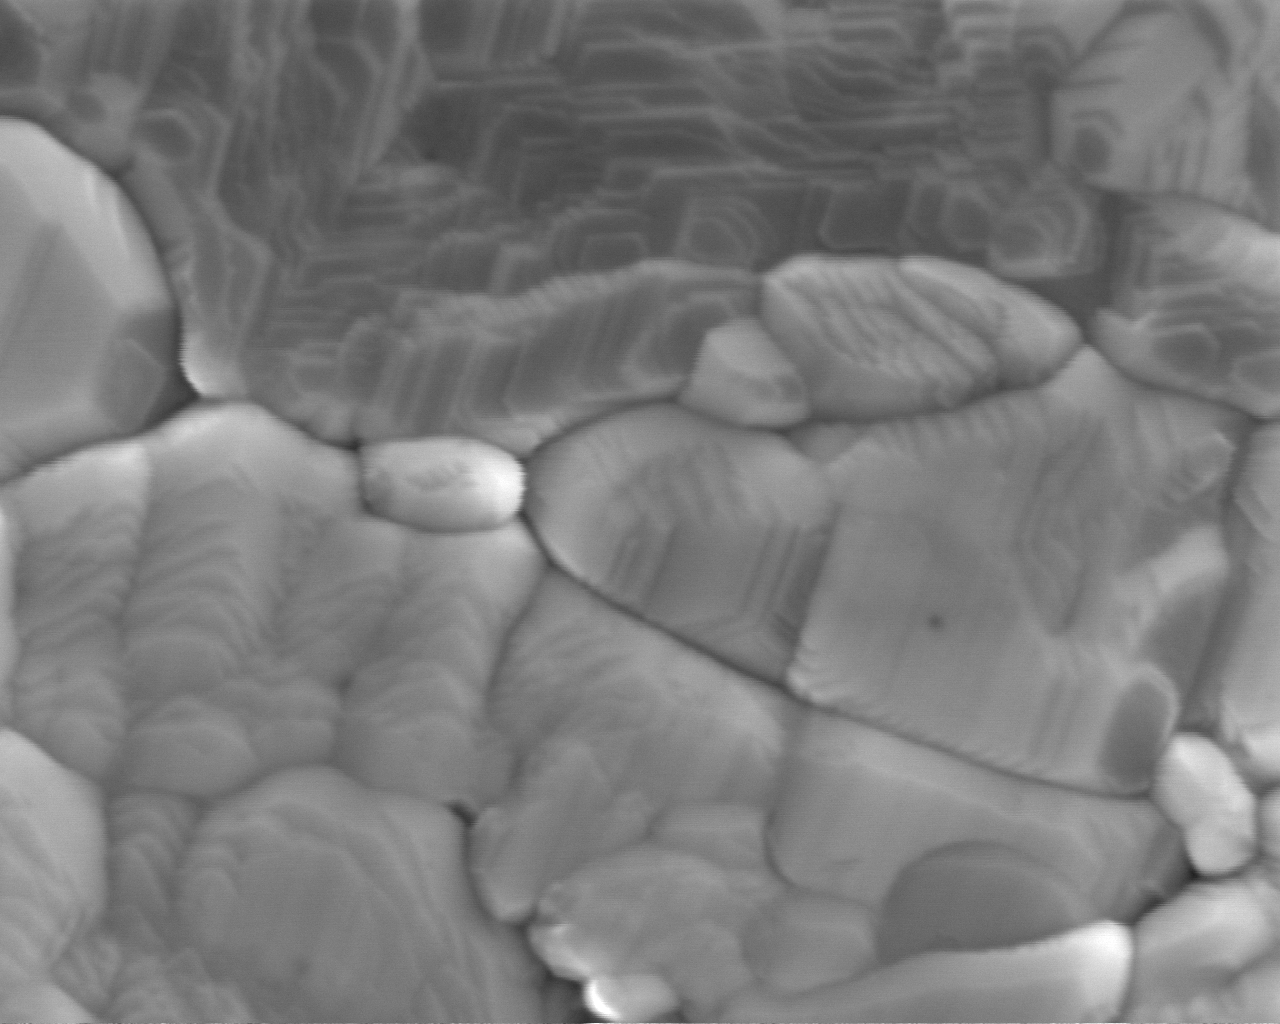


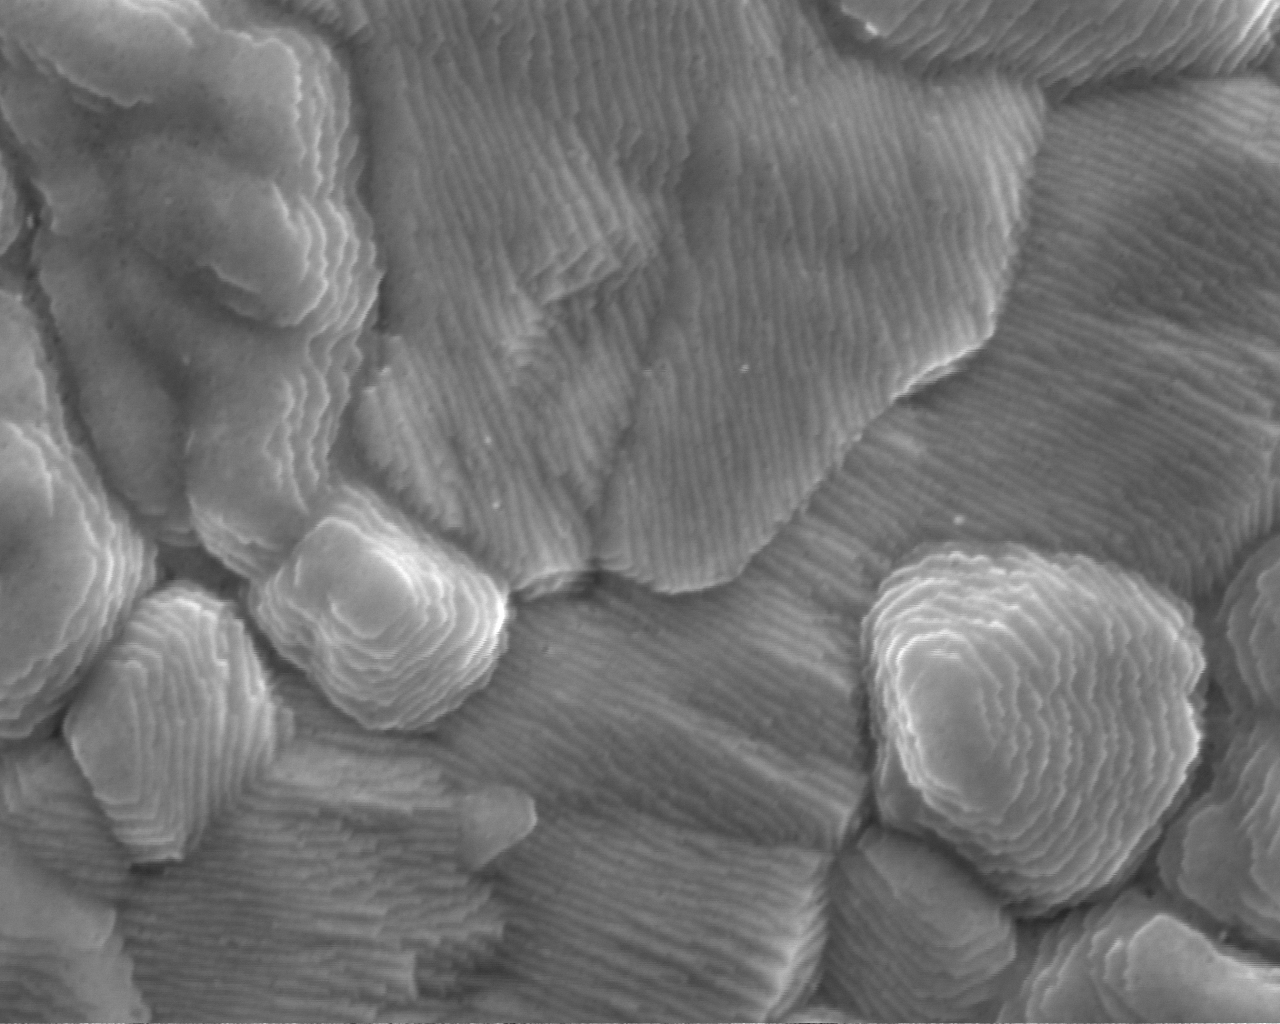


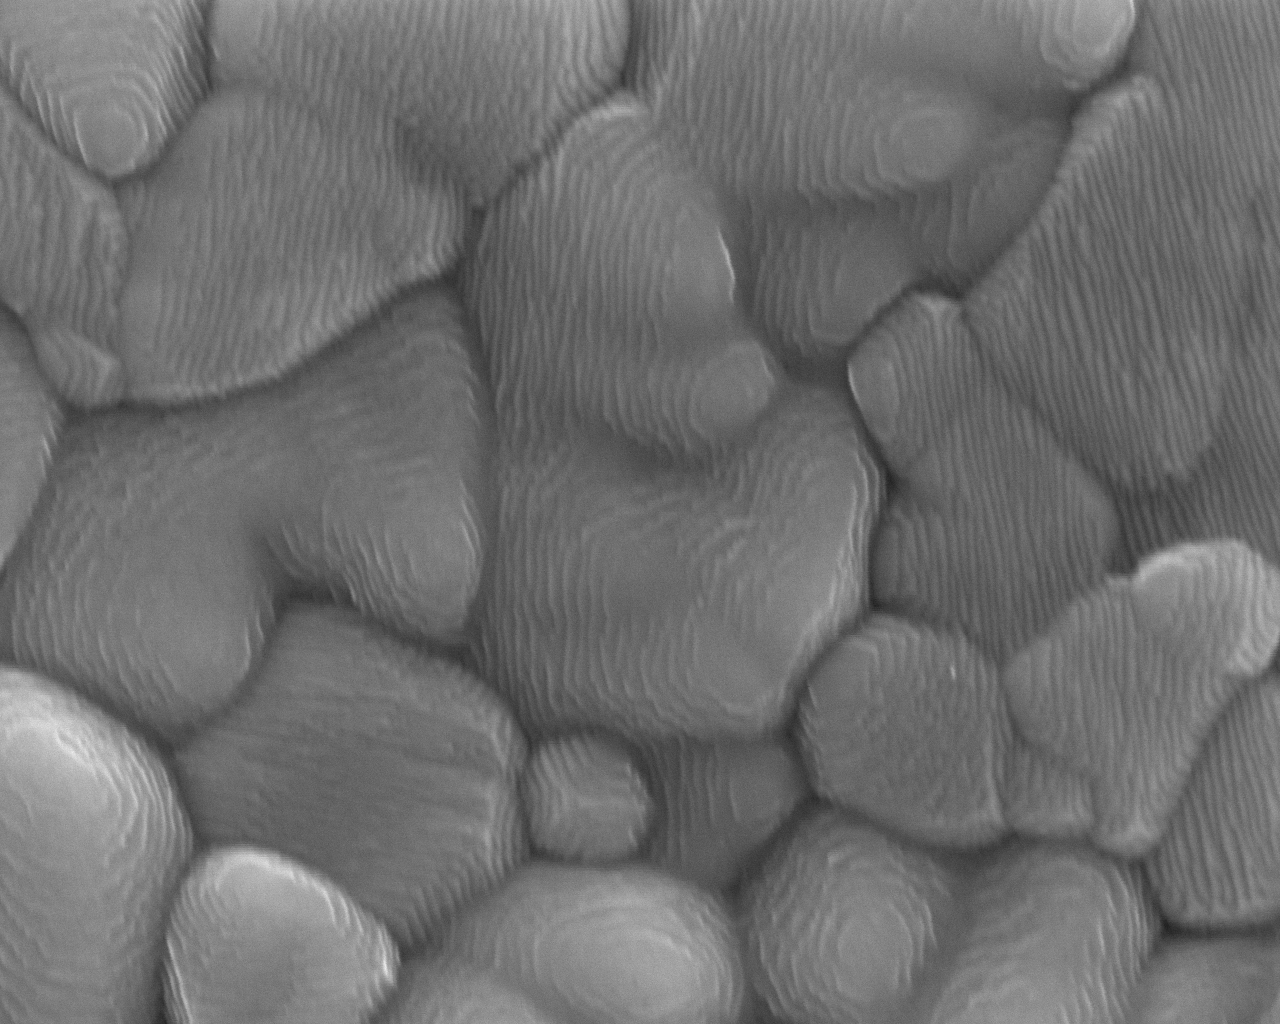

Fabrication rows add geometry (domed buttons, thickness and radius recorded), heat treatment (max temperature, time), grain orientation and chemical composition for all nine.

**What they were exposed to — verified against raw signals, not just recorded.** The samples sat at the DiMES position at the outer strike point through 5 (H) or 4 (L) discharges, flat-top 2500–5000 ms each, 12.5 s vs 10.0 s total. Three independent rebuilds from delivered raw data confirmed the recorded conditions: the Langmuir-probe rebuild reproduced the recorded Te/ne at the sample; the IR-camera rebuild reproduced the recorded heat fluxes (0.72/0.47 MW m⁻² recorded; 0.70/0.473 rebuilt, and showed the recorded "Avg" is a flat-top, all-position mean while the recorded "Max" is itself a time-average of per-frame peaks); and the filterscope rebuild reproduced the recorded FASTCAM intra/inter-ELM ratio (4.2 recorded vs 3.92 ± 0.68 for a peak-of-ELM measure) while exposing that the stored ELM windows' padding dilutes a whole-window measure to 1.93.

**The ELM history, cross-validated.** The H-mode samples rode through **955 validated ELMs** (152–230 per shot, 61–92 Hz, sub-millisecond FWHM 0.56–1.18 ms), with peak heat fluxes **4.4–5.9× the mean** (up to 4.4 MW m⁻²) against an inter-ELM baseline *below* the average. The L-mode samples saw **zero** — the detector's 213–245 marks per L shot carry no D-alpha enhancement (1.05× inside vs out) and the IR shows no transients, so the record's L labels stand. The detector's H counts match the independent IR census to within 0–2 events on the two shots where both exist.

**What came out.** Retention was measured by three methods on all nine. Campaign means: ERDA **1.10 ± 0.23 (H) vs 1.96 ± 0.27 (L)** ×10¹⁵ cm⁻²; NRA 0–3 µm **1.74 ± 0.55 vs 3.51 ± 0.71** . Normalised by recorded fluence, the L-mode surfaces kept **~50–75 % more deuterium per incident ion** . Within each campaign, He pre-exposure reorders the samples by up to a factor 2.2 — as large as the between-campaign effect. The He inventory itself survives the DIII-D exposure (LAMS APPM profiles to ~2 µm).

## Consistent with the data, but not established

- **ELM-suppression of retention.** The direction matches (ELM-free → more retention), but the two campaigns differ simultaneously in ELM count, Te (27.9 vs 40.8 eV), impact energy (150 vs 175 eV) and fluence — **one contrast, n = 1** , perfectly confounded. The data is consistent with ELM-driven outgassing/erosion keeping H inventories low; equally consistent with higher L-mode Te driving deeper implantation.
- **He-induced traps explaining the pre-treatment ordering.** The ordering is measured; the trap mechanism is not — the NRA depth bands (0–0.5, 0.5–3 µm) are too coarse to localise any ELM or He effect, and within-campaign spread shows coupon-to-coupon variation of the same size.
- **ELM surface damage on the H coupons.** The exposure demonstrably delivered ~1000 thermal transients to those surfaces, and the physics of cyclic sub-ms loading is consistent with roughening or crack initiation — but no post-exposure image of any exposed sample exists in the delivery to show it.

## What this record cannot address at all

- **Post-exposure surface state.** The Data Availability Sheet has a Post-exposure SEM column; the delivered version carries template headers with no status marks or data, and the artifact catalogue holds zero post-exposure images. Any statement about what the surfaces look like now would be invention.
- **Surface temperature during ELMs.** Only heat flux was delivered; no IR thermography or temperature calibration, so transient surface temperature — the quantity that governs melt-layer and crack behaviour — is not recoverable.
- **Actual erosion of these coupons.** The workbook's "Surface erosion during H-mode" block holds three normalised power-law curves (W, W-He600, W-He800, depth to 500 nm, no uncertainties) — a modelled material-class comparison, H-mode only, not a measurement on the six exposed coupons.
- **The two H shots whose IR files arrived empty** (185259, 185265 — the files exist but contain a single zero row / truncated header): their transient loading is inferred from the three usable shots only.
- **Statistical strength.** One sample per cell, one campaign per regime: no replication anywhere in the design.

## What would settle the open questions

1. **Post-exposure SEM at the pre-existing fields and magnifications** — the pre-set already exists (matched 50k× IMG01 fields per coupon class), so a repeat acquisition would make morphology change a paired measurement. This single dataset settles ELM damage, He-pre-exposure roughening, and the erosion question's surface expression at once.
2. **Fine near-surface D profiling** (sub-0.5 µm LAMS resolution) on H vs L coupons — if ELMs suppress retention, the deficit should sit in the top implantation band; if Te drives it, the profile deepens instead.
3. **A matched-conditions ELMy/ELM-free pair** — DIII-D H-mode at the L-campaign's surface Te, or vice versa — to break the Te/energy/fluence confound. The lakehouse's exposure index plus the ELM index can find candidate shots.
4. **Coupon-level erosion measurements** (mass loss, profilometry, or the in-situ emission spectroscopy the proposal planned) in place of the modelled curves.
5. **IR thermography calibrated to surface temperature, and re-delivery of the two empty qpeak files** , to close the transient temperature history and complete the H-campaign loading record.

Working artifacts from this pass: `syn_00_inventory.py` … `syn_05_fills.py` (evidence-gathering scripts) and the three converted `sem_pre_*.png` fields shown above.

In [1]:
%%ask --review
Summarise what this combined record establishes about how these tungsten
samples were exposed and what happened to them, drawing on the surface images,
the retention measurements, the raw plasma data you rebuilt, and the archive.

Be clear about which conclusions the data supports, which are consistent with
it but not established, and which questions it cannot address at all. Then say
what additional samples or measurements would settle the open ones.